# Folder Scan: Anisotropy and Theta

Standalone overview: set `DATA_DIR` in Cell 2, then run all cells. The scanner handles `.tdms` APD recordings and numeric `.npy` camera stacks shaped `(frames, H, W)`. It ignores `spotrec_preview_*.npy`, `.stop`, index files, and JSON files as standalone inputs. Each NPY looks for its **same-stem `.json`** beside it; old absolute paths recorded inside JSON are not followed.

Each recording produces **two figures**. TDMS retains the raw/corrected anisotropy comparison and three theta stages. Camera data have one as-saved anisotropy panel and two theta stages (full pupil and hole + Fresnel), because **camera gain fitting and inverse-matrix correction are skipped**. Both anisotropy axes are fixed to [-1, 1], with out-of-range histogram points ignored, not clipped.

TDMS uses the original per-file inverse-gain fit followed by inverse T. `BLOCK_US = 80` sets channel averaging before ratios; for camera FPS too slow to supply an 80 us block, one complete frame is used instead and the actual interval is printed. There is no temporal upsampling. Invalid angles remain NaN.

## Camera Metadata and Crops

- Timing comes from `actual.fps` (or `fetch_frames_output.actual_fps`), not requested FPS. A declared trailing phase-marker frame is verified and removed; absent a declaration, an exact one-pixel-value-1 trailing marker is removed with a warning. Frame-count mismatches are reported as errors.
- Sensor ROI origins accept `x/y/w/h` or `OffsetX/OffsetY/Width/Height`. The mosaic is I90=(even row, even col), I45=(even, odd), I135=(odd, even), I0=(odd, odd). Assignment uses **absolute sensor coordinates of the final crop**. JSON `phase_x/phase_y`, when present, must agree with the hardware ROI parity; they are not added a second time.
- `CAMERA_CROP_XYWH = None` uses `rod_location.center_px` (absolute sensor x/y) and `roi.win_raw` or `requested.roi_raw` to choose a spot window. Its integer top-left is floor(center - half-window), constrained to the saved ROI. This is an explicit crop convention, not a promise of identical GUI pixel selection. The selected crop is printed.
- If no rod center/window is available, all saved pixels are pooled, with a warning and **whole saved ROI aggregate** plot label. This is not a single-rod orientation measurement when multiple objects are present. Set `CAMERA_CROP_XYWH = (x, y, width, height)` in absolute sensor coordinates to isolate a rod; this override applies to every NPY in that scan.
- Spatial means are computed independently for the four analyzers before ratios. Odd trailing rows/columns are discarded to retain equal analyzer pixel counts. Large NPY files are memory-mapped and reduced in frame chunks. Saved acquisition background subtraction is reported and preserved; no new background is subtracted, and no negative values are lifted.
- Missing sidecars or missing fields are warned about. **`CAMERA_FPS_FALLBACK = None` skips files lacking measured FPS**; set a positive fallback only when you know the rate. Missing ROI origin uses the warned `CAMERA_ORIGIN_FALLBACK_XY = (0, 0)` assumption, or set this to `None` to reject missing origins. Malformed JSON, contradictory phase/ROI metadata, or declared-but-missing markers are skipped rather than guessed.

Two PNGs are saved under `OUTPUT_DIR`, retaining relative subfolders; rerunning replaces those PNGs. Camera names retain `.npy` before the plot suffix to avoid colliding with a same-stem TDMS file. `SHOW_PLOTS` controls display, not saving. `SCAN_RESULTS` records successes/errors and the camera metadata actually used. Circle fitting is diagnostic only: a failed fit omits the overlay but does not stop either plot. Unreadable recordings are reported and skipped.

Dependencies: Python 3.10+, NumPy, SciPy, Matplotlib, npTDMS, and IPython. No other notebook or local analysis module is required. No state fitting, transitions, sphere analysis, recentering, or rescaling is performed.

In [17]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.optimize import minimize
from nptdms import TdmsFile
from IPython.display import display

DATA_DIR = Path('data') / 'remember to correct save pathing from hugh'
# DATA_DIR = Path('data') / 'Hinge apd recordings, 2 strand + notches'
RECURSIVE = True
OUTPUT_DIR = DATA_DIR / 'overview_plots'
SHOW_PLOTS = True
BLOCK_US = 80.0
THETA_TIME_BIN_S = 0.010
NA, NA_IN = 1.3, 0.38
N_WATER, N_OIL = 1.33, 1.515
FIT_CIRCLE = True
RIM_SECTOR_DEG = (130., 230.)
RIM_BINS, RIM_EXTREME_POINTS = 90, 3
CAMERA_FPS_FALLBACK = None
CAMERA_ORIGIN_FALLBACK_XY = (0, 0)
CAMERA_CROP_XYWH = None

In [18]:
def full_pupil_coefficients(na, refractive_index):
    if not np.all(np.isfinite([na, refractive_index])) or not 0 < na <= refractive_index:
        raise ValueError('Require 0 < NA <= refractive index')
    cosine = np.cos(np.arcsin(na / refractive_index))
    return (1/6 - cosine/4 + cosine**3/12,
            cosine/8 - cosine**3/8,
            7/48 - cosine/16 - cosine**2/16 - cosine**3/48)

def fresnel_coefficients(na, n_water, n_oil, na_inner):
    if (not np.all(np.isfinite([na, n_water, n_oil, na_inner]))
            or not 0 <= na_inner < na <= min(n_water, n_oil)):
        raise ValueError('Require 0 <= NA_IN < NA <= min(N_WATER, N_OIL)')
    nodes, weights = np.polynomial.legendre.leggauss(128)
    pupil_radius = na_inner + (nodes + 1) * (na - na_inner) / 2
    sin_water = pupil_radius / n_water
    cos_water = np.sqrt(1 - sin_water**2)
    cos_oil = np.sqrt(1 - (pupil_radius / n_oil)**2)
    transmission_s = 2 * n_water * cos_water / (n_water * cos_water + n_oil * cos_oil)
    transmission_p = 2 * n_water * cos_water / (n_oil * cos_water + n_water * cos_oil)
    field_weight = np.sqrt(cos_oil) / cos_water
    measure = weights * (na - na_inner) / 2 * pupil_radius * field_weight**2 / n_water**2
    radial_field = transmission_p * cos_water
    coeff_a = np.sum(measure * transmission_p**2 * sin_water**2) / 4
    coeff_a_plus_b = np.sum(measure * (radial_field**2 + transmission_s**2)) / 8
    coeff_c = np.sum(measure * (radial_field + transmission_s)**2) / 16
    return coeff_a, coeff_a_plus_b - coeff_a, coeff_c

def theta_from_radius(radius, coefficients):
    coeff_a, coeff_b, coeff_c = coefficients
    radius = np.asarray(radius, dtype=float)
    rmax = coeff_c / (coeff_a + coeff_b)
    tolerance = 16 * np.finfo(float).eps * max(1., abs(rmax))
    valid = np.isfinite(radius) & (radius >= 0) & (radius <= rmax + tolerance)
    radius_used = np.where(valid, np.minimum(radius, rmax), np.nan)
    sine_squared = np.clip(coeff_a * radius_used / (coeff_c - coeff_b * radius_used), 0., 1.)
    return np.degrees(np.arcsin(np.sqrt(sine_squared)))

In [19]:
def camera_channel_means(frames, origin_xy, *, chunk_frames=256):
    """Spatial means per analyzer, using absolute sensor parity and complete 2x2 blocks."""
    if frames.ndim != 3 or not np.issubdtype(frames.dtype, np.number) or np.iscomplexobj(frames):
        raise ValueError('Camera data must have numeric shape (frames, height, width)')
    origin = np.asarray(origin_xy, dtype=float)
    if origin.shape != (2,) or not np.all(np.isfinite(origin)) or np.any(origin != np.floor(origin)):
        raise ValueError('Camera origin must be integer sensor coordinates (x, y)')
    if isinstance(chunk_frames, bool) or int(chunk_frames) != chunk_frames or chunk_frames < 1:
        raise ValueError('chunk_frames must be a positive integer')
    height, width = (dimension // 2 * 2 for dimension in frames.shape[1:])
    if not len(frames) or min(height, width) < 2:
        raise ValueError('Camera recording needs at least one frame and one complete 2x2 block')
    channels = np.empty((len(frames), 4), dtype=float)
    sensor_parities = ((1, 1), (0, 0), (0, 1), (1, 0))
    origin_x, origin_y = (int(value) for value in origin)
    for channel_index, (sensor_row, sensor_col) in enumerate(sensor_parities):
        row_start = (sensor_row - origin_y) % 2
        col_start = (sensor_col - origin_x) % 2
        for start in range(0, len(frames), int(chunk_frames)):
            stop = min(start + int(chunk_frames), len(frames))
            channels[start:stop, channel_index] = frames[
                start:stop, row_start:height:2, col_start:width:2
            ].mean(axis=(1, 2), dtype=np.float64)
    return channels

def load_camera(path, *, fps_fallback=None, origin_fallback=(0, 0), crop_xywh=None):
    """Load a saved camera stack and its same-stem JSON, without new background subtraction."""
    import json
    import warnings
    path = Path(path)
    sidecar = path.with_suffix('.json')
    if sidecar.is_file():
        metadata = json.loads(sidecar.read_text(encoding='utf-8-sig'))
        if not isinstance(metadata, dict):
            raise ValueError('Camera sidecar must contain a JSON object')
    else:
        metadata = {}
        warnings.warn(f'{path.name}: JSON sidecar missing; timing and sensor origin need explicit assumptions', RuntimeWarning)
    actual = metadata.get('actual', {})
    acquisition = metadata.get('fetch_frames_output', {})
    rate = actual.get('fps', acquisition.get('actual_fps'))
    if rate is None:
        if fps_fallback is None:
            raise ValueError('Missing actual.fps; set CAMERA_FPS_FALLBACK explicitly to use an assumed rate')
        rate = fps_fallback
        warnings.warn(f'{path.name}: using fallback camera FPS={rate}', RuntimeWarning)
    rate = float(rate)
    if not np.isfinite(rate) or rate <= 0:
        raise ValueError('Camera FPS must be positive and finite')
    frames = np.load(path, mmap_mode='r', allow_pickle=False)
    if (frames.ndim != 3 or not len(frames) or min(frames.shape[1:]) < 2
            or not np.issubdtype(frames.dtype, np.number) or np.iscomplexobj(frames)):
        raise ValueError('Expected a nonempty numeric camera stack (frames, height, width)')
    marker_declared = actual.get('phase_marker_appended', acquisition.get('phase_marker_appended'))
    if marker_declared is not None and not isinstance(marker_declared, bool):
        raise ValueError('phase_marker_appended must be true or false')
    marker_present = np.count_nonzero(frames[-1]) == 1 and np.max(frames[-1]) == 1
    if marker_declared is True and not marker_present:
        raise ValueError('JSON declares a phase marker but the last frame is not a one-pixel marker')
    marker_removed = bool(marker_present and marker_declared is not False)
    if marker_removed:
        if marker_declared is None:
            warnings.warn(f'{path.name}: removing inferred trailing one-pixel phase marker', RuntimeWarning)
        frames = frames[:-1]
    if not len(frames):
        raise ValueError('No camera observations remain after removing the phase marker')
    declared_count = actual.get('frames', acquisition.get('count'))
    if declared_count is not None and declared_count != len(frames):
        raise ValueError(f'JSON frame count {declared_count} differs from {len(frames)} saved observations')

    def integer(value, name):
        number = float(value)
        if not np.isfinite(number) or number != np.floor(number):
            raise ValueError(f'{name} must be a finite integer')
        return int(number)

    roi = metadata.get('roi') or acquisition.get('roi', {})
    origin_x = roi.get('x', roi.get('OffsetX'))
    origin_y = roi.get('y', roi.get('OffsetY'))
    if origin_x is None or origin_y is None:
        if origin_fallback is None or len(origin_fallback) != 2:
            raise ValueError('Missing sensor ROI origin; set CAMERA_ORIGIN_FALLBACK_XY explicitly')
        origin_x, origin_y = origin_fallback
        warnings.warn(f'{path.name}: using fallback sensor origin {(origin_x, origin_y)}', RuntimeWarning)
    origin_x, origin_y = integer(origin_x, 'ROI x'), integer(origin_y, 'ROI y')
    if min(origin_x, origin_y) < 0:
        raise ValueError('Sensor ROI origin cannot be negative')
    height, width = frames.shape[1:]
    for saved_size, declared_size, name in ((width, roi.get('w', roi.get('Width')), 'width'),
                                            (height, roi.get('h', roi.get('Height')), 'height')):
        if declared_size is not None and integer(declared_size, name) != saved_size:
            raise ValueError(f'JSON ROI {name} does not match the saved frame shape')
    for key, coordinate in (('phase_x', origin_x), ('phase_y', origin_y)):
        if key in roi and integer(roi[key], key) != coordinate % 2:
            raise ValueError(f'{key} conflicts with absolute sensor ROI parity; verify the sidecar')

    center = metadata.get('rod_location', {}).get('center_px')
    if not center and 'cx' in roi and 'cy' in roi:
        center = {'x': roi['cx'], 'y': roi['cy']}
    window_size = roi.get('win_raw', metadata.get('requested', {}).get('roi_raw'))
    if crop_xywh is not None:
        if len(crop_xywh) != 4:
            raise ValueError('CAMERA_CROP_XYWH must be absolute sensor (x, y, width, height)')
        crop_x, crop_y, crop_width, crop_height = (integer(value, 'crop') for value in crop_xywh)
        local_x, local_y = crop_x - origin_x, crop_y - origin_y
        if min(local_x, local_y) < 0 or crop_width < 2 or crop_height < 2 or local_x + crop_width > width or local_y + crop_height > height:
            raise ValueError('Requested camera crop lies outside the saved ROI or is smaller than 2x2')
        crop_source = 'explicit sensor crop'
    elif center and window_size is not None:
        center_x, center_y = float(center['x']) - origin_x, float(center['y']) - origin_y
        if not np.all(np.isfinite([center_x, center_y])) or not (0 <= center_x < width and 0 <= center_y < height):
            raise ValueError('Recorded rod center lies outside the saved ROI')
        window_size = integer(window_size, 'rod window')
        if window_size < 2:
            raise ValueError('Rod window must contain a complete 2x2 block')
        crop_width, crop_height = min(window_size, width), min(window_size, height)
        local_x = int(np.clip(np.floor(center_x - crop_width / 2), 0, width - crop_width))
        local_y = int(np.clip(np.floor(center_y - crop_height / 2), 0, height - crop_height))
        crop_source = 'recorded rod center/window'
    else:
        local_x = local_y = 0
        crop_width, crop_height = width, height
        crop_source = 'whole saved ROI aggregate'
        warnings.warn(f'{path.name}: no rod crop selected; pooling the whole saved ROI, not a single-rod trace. Set CAMERA_CROP_XYWH to isolate a rod.', RuntimeWarning)
    crop_width, crop_height = crop_width // 2 * 2, crop_height // 2 * 2
    absolute_origin = (origin_x + local_x, origin_y + local_y)
    cropped = frames[:, local_y:local_y + crop_height, local_x:local_x + crop_width]
    channels = camera_channel_means(cropped, absolute_origin)
    background_subtracted = metadata.get('background', {}).get('background_subtracted', acquisition.get('background_subtracted'))
    info = dict(sidecar=str(sidecar) if sidecar.is_file() else None, frames=len(frames),
                marker_removed=marker_removed, roi_origin_xy=(origin_x, origin_y),
                crop_xywh=(*absolute_origin, crop_width, crop_height), crop_source=crop_source,
                background_subtracted=background_subtracted)
    return channels, rate, info

In [20]:
INVERSE_T = np.array([
    [2.56410256, 0., 0., 0.],
    [0., 2.65305220, 0., 0.],
    [-0.04047189, 0.04187587, 1.87478350, -0.00045528],
    [-0.04045247, 0.04185578, -0.00046721, 1.82373830],
])

def load_channels(path):
    recording = TdmsFile.read(path)
    groups = recording.groups()
    if not groups or len(groups[0].channels()) != 4:
        raise ValueError('Expected four APD channels in the first TDMS group')
    channels = groups[0].channels()
    lengths = [len(channel) for channel in channels]
    if not lengths[0] or len(set(lengths)) != 1:
        raise ValueError('Channels must be nonempty and have equal lengths')
    interval = float(channels[0].properties.get('wf_increment', 4e-6))
    if not np.isfinite(interval) or interval <= 0:
        raise ValueError('Invalid TDMS sampling interval')
    for channel in channels[1:]:
        if not np.isclose(float(channel.properties.get('wf_increment', interval)), interval, rtol=1e-9, atol=0):
            raise ValueError('Channel sampling intervals differ')
    values = np.column_stack([np.asarray(channels[index][:], dtype=float) for index in (3, 0, 1, 2)])
    return values, 1 / interval

def prepare_recording(channels, rate, block_us, coefficients, *, correct_apd=True):
    """Channel means before ratios; only APD data receive fitted gains and inverse T."""
    channels = np.asarray(channels, dtype=float)
    if channels.ndim != 2 or channels.shape[1] != 4:
        raise ValueError('Expected columns in logical order 0, 90, 45, 135')
    if not np.all(np.isfinite([rate, block_us])) or rate <= 0 or block_us <= 0:
        raise ValueError('Sample rate and integration time must be positive and finite')
    block_size = max(1, int(round(block_us * 1e-6 * rate)))
    complete = len(channels) // block_size * block_size
    if complete == 0:
        raise ValueError('Recording is shorter than one averaging block')
    gains = None
    inputs = [('raw', channels)]
    if correct_apd:
        finite_rows = np.all(np.isfinite(channels), axis=1)
        if np.count_nonzero(finite_rows) < 3:
            raise ValueError('At least three finite native samples are required for gain fitting')
        weighted = channels[finite_rows] * (np.array([1., 1., -1., -1.]) @ INVERSE_T)
        solution, *_ = np.linalg.lstsq(weighted[:, 1:], -weighted[:, 0], rcond=None)
        gains = np.concatenate(([1.], solution))
        if not np.all(np.isfinite(gains)):
            raise ValueError('Gain fitting returned nonfinite values')
        del weighted
        corrected = (channels * gains) @ INVERSE_T.T
        inputs.append(('corrected', corrected))
    stage_data = {}
    for name, values in inputs:
        means = values[:complete].reshape(-1, block_size, 4).mean(axis=1)
        denominator_x = means[:, 0] + means[:, 1]
        denominator_y = means[:, 2] + means[:, 3]
        usable = np.all(np.isfinite(means), axis=1) & (denominator_x > 0) & (denominator_y > 0)
        x_values = np.divide(means[:, 0] - means[:, 1], denominator_x,
                             out=np.full(len(means), np.nan), where=usable)
        y_values = np.divide(means[:, 2] - means[:, 3], denominator_y,
                             out=np.full(len(means), np.nan), where=usable)
        stage_data[name] = dict(ax=x_values, ay=y_values, photometry_valid=usable & np.all(means >= 0, axis=1))
    stage_data['fresnel'] = dict(stage_data['corrected' if correct_apd else 'raw'])
    for name, stage in stage_data.items():
        model = coefficients['fresnel' if name == 'fresnel' else 'full']
        angles = theta_from_radius(np.hypot(stage['ax'], stage['ay']), model)
        stage['theta'] = np.where(stage['photometry_valid'], angles, np.nan)
        stage['valid_angle'] = np.isfinite(stage['theta'])
    times = (np.arange(complete // block_size) * block_size + (block_size - 1) / 2) / rate
    return dict(stages=stage_data, times=times, rate=rate / block_size, gains=gains,
                source='tdms' if correct_apd else 'camera',
                block_us=block_size / rate * 1e6, trailing_samples=len(channels) - complete,
                rmax=coefficients['fresnel'][2] / sum(coefficients['fresnel'][:2]))

def fit_circle(x_values, y_values):
    """Diagnostic rim fit; reject radii over 100 times the edge span as effectively unbounded."""
    points = np.column_stack((x_values, y_values))
    points = points[np.all(np.isfinite(points), axis=1)]
    if len(points) == 0:
        raise ValueError('No valid corrected points for a circle fit')
    mean_x, mean_y = points.mean(axis=0)
    bearings = np.degrees(np.arctan2(points[:, 1] - mean_y, points[:, 0] - mean_x)) % 360
    radius = np.hypot(points[:, 0] - mean_x, points[:, 1] - mean_y)
    bins = np.digitize(bearings, np.linspace(0, 360, RIM_BINS + 1)) - 1
    edges = []
    for bin_index in range(RIM_BINS):
        selected = bins == bin_index
        if np.count_nonzero(selected) > max(30, RIM_EXTREME_POINTS):
            outer = np.argsort(radius[selected])[-RIM_EXTREME_POINTS:]
            edge_x, edge_y = points[selected][outer].mean(axis=0)
            bearing = np.degrees(np.arctan2(edge_y - mean_y, edge_x - mean_x)) % 360
            if RIM_SECTOR_DEG[0] < bearing < RIM_SECTOR_DEG[1]:
                edges.append((edge_x, edge_y))
    if len(edges) < 4:
        raise ValueError('Fewer than four populated rim bins in the selected sector')
    edges = np.asarray(edges)
    fit = minimize(lambda parameters: np.sum((
        np.hypot(edges[:, 0] - parameters[0], edges[:, 1] - parameters[1]) - parameters[2])**2),
        [-.3, 0., .6], method='Nelder-Mead')
    if not fit.success or not np.all(np.isfinite(fit.x)) or fit.x[2] <= 0:
        raise ValueError(f'Circle fit failed: {fit.message}')
    edge_span = max(float(np.ptp(edges, axis=0).max()), np.finfo(float).eps)
    if fit.x[2] > 100 * edge_span:
        raise ValueError('Circle fit is effectively unbounded relative to the observed edge span')
    return dict(center=fit.x[:2], radius=float(fit.x[2]), edges=edges)

In [21]:
def make_figures(data, label, *, fit_rim=True, theta_time_bin_s=0.010):
    if not np.isfinite(theta_time_bin_s) or theta_time_bin_s <= 0:
        raise ValueError('THETA_TIME_BIN_S must be positive and finite')
    stages = data['stages']
    camera = data.get('source') == 'camera'
    anisotropy_stages = ('raw',) if camera else ('raw', 'corrected')
    theta_stages = ('raw', 'fresnel') if camera else ('raw', 'corrected', 'fresnel')
    titles = {'raw': 'Raw\nFull-pupil estimate (uncalibrated)',
              'corrected': 'Raw + gains + inverse matrix\nFull-pupil estimate',
              'fresnel': 'Raw + gains + inverse matrix\nHole + Fresnel estimate'}
    if camera:
        titles = {'raw': 'Camera (as saved)\nFull-pupil estimate',
                  'fresnel': 'Camera (as saved)\nHole + Fresnel estimate'}
    circle = None
    if fit_rim:
        try:
            rim_stage = stages['raw' if camera else 'corrected']
            mask = rim_stage['photometry_valid']
            circle = fit_circle(rim_stage['ax'][mask], rim_stage['ay'][mask])
        except Exception as error:
            print(f'{label}: circle overlay omitted ({type(error).__name__}: {error})')
    extent = 1.
    histograms = {}
    for name in anisotropy_stages:
        stage = stages[name]
        finite = np.isfinite(stage['ax']) & np.isfinite(stage['ay'])
        histograms[name], _, _ = np.histogram2d(stage['ax'][finite], stage['ay'][finite],
                                               bins=140, range=[[-extent, extent], [-extent, extent]])
    color_norm = LogNorm(vmin=1, vmax=max(2, *(histogram.max() for histogram in histograms.values())))
    anisotropy_figure, axes = plt.subplots(1, len(anisotropy_stages), figsize=(7, 5.8) if camera else (12.8, 5.8),
                                          sharex=True, sharey=True, layout='constrained')
    axes = np.atleast_1d(axes)
    for axis, name in zip(axes, anisotropy_stages):
        image = axis.imshow(histograms[name].T, origin='lower', extent=[-extent, extent, -extent, extent],
                            norm=color_norm, cmap='inferno', interpolation='nearest')
        if camera or name == 'corrected':
            axis.add_patch(plt.Circle((0, 0), data['rmax'], fill=False, color='0.4', lw=1, ls='--',
                                      label=f'r_max (hole + Fresnel)={data["rmax"]:.6f}'))
            if circle is not None:
                axis.add_patch(plt.Circle(circle['center'], circle['radius'], fill=False, color='tab:cyan', lw=1.2, ls=':',
                                          label=f'edge circle R={circle["radius"]:.5f}'))
                axis.scatter(*circle['center'], marker='+', s=70, color='tab:cyan')
                axis.scatter(circle['edges'][:, 0], circle['edges'][:, 1], s=8, color='tab:cyan')
            axis.legend(fontsize=7.5, loc='upper right', facecolor='white', framealpha=.9)
        axis.axhline(0, color='0.6', lw=.4)
        axis.axvline(0, color='0.6', lw=.4)
        axis.set(xlabel='$a_x$', ylabel='$a_y$', aspect='equal', xlim=(-1, 1), ylim=(-1, 1),
                 title=('Camera (as saved)\nNo gain or matrix correction' if camera else
                        titles[name] if name == 'raw' else 'Raw + gains + inverse matrix'))
    anisotropy_figure.colorbar(image, ax=axes, label='blocks / bin (log scale)', shrink=.85, pad=.01)
    anisotropy_figure.suptitle(str(label), fontsize=12)

    times = data['times']
    time_start, time_end = times[0] - .5 / data['rate'], times[-1] + .5 / data['rate']
    time_bins = max(1, int(np.ceil((time_end - time_start) / theta_time_bin_s)))
    time_edges = np.linspace(time_start, time_end, time_bins + 1)
    angle_edges = np.linspace(0, 90, 91)
    theta_figure, theta_axes = plt.subplots(len(theta_stages), 2, figsize=(13, 3.5 * len(theta_stages)),
                                           gridspec_kw={'width_ratios': [3, 1]}, layout='constrained')
    for row, name in enumerate(theta_stages):
        stage = stages[name]
        valid = stage['valid_angle']
        angles = stage['theta'][valid]
        counts, _, _ = np.histogram2d(times[valid], angles, bins=[time_edges, angle_edges])
        theta_axes[row, 0].imshow(np.log1p(counts.T), origin='lower', aspect='auto', cmap='inferno',
                                  interpolation='nearest', extent=[time_start, time_end, 0, 90])
        theta_axes[row, 0].set(xlabel='t (s)', ylabel='estimated theta (deg)', title=titles[name])
        if len(angles):
            theta_axes[row, 1].hist(angles, bins=angle_edges, density=True, histtype='step', color='tab:blue')
        else:
            theta_axes[row, 1].text(.5, .5, 'No valid angles', ha='center', va='center', transform=theta_axes[row, 1].transAxes)
        theta_axes[row, 1].set(xlabel='estimated theta (deg)', ylabel='density / deg', xlim=(0, 90),
                              title=f'All valid blocks ({len(angles):,}/{len(times):,})')
    theta_figure.suptitle(f'{label}\nEmpirical theta occupancy (log counts) and angle distributions', fontsize=12)
    return anisotropy_figure, theta_figure

Found 22 recordings (0 TDMS, 22 camera NPY) in C:\Users\denny\workspace\anisotropy-rotation-analysis\data\remember to correct save pathing from hugh

[1/22] spotrec_20260918-145944.npy
spotrec_20260918-145944.npy: camera 1526.40264 FPS, 56,736 frames; marker removed=True; recorded rod center/window, crop=(642, 914, 10, 10); acquisition background subtraction=True.


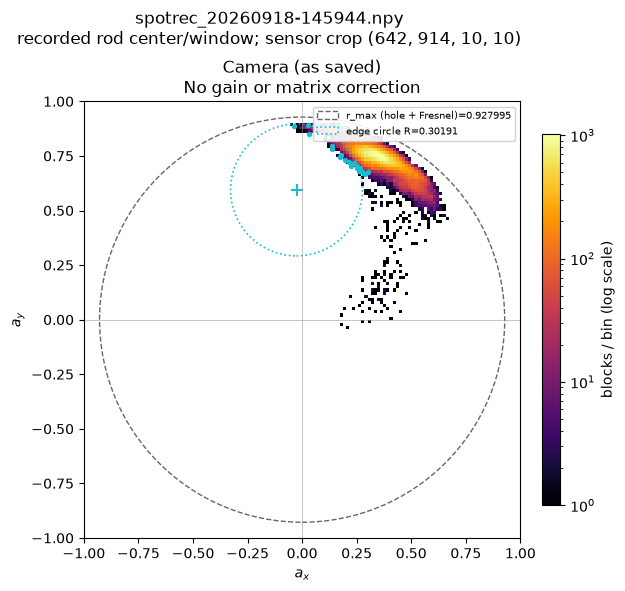

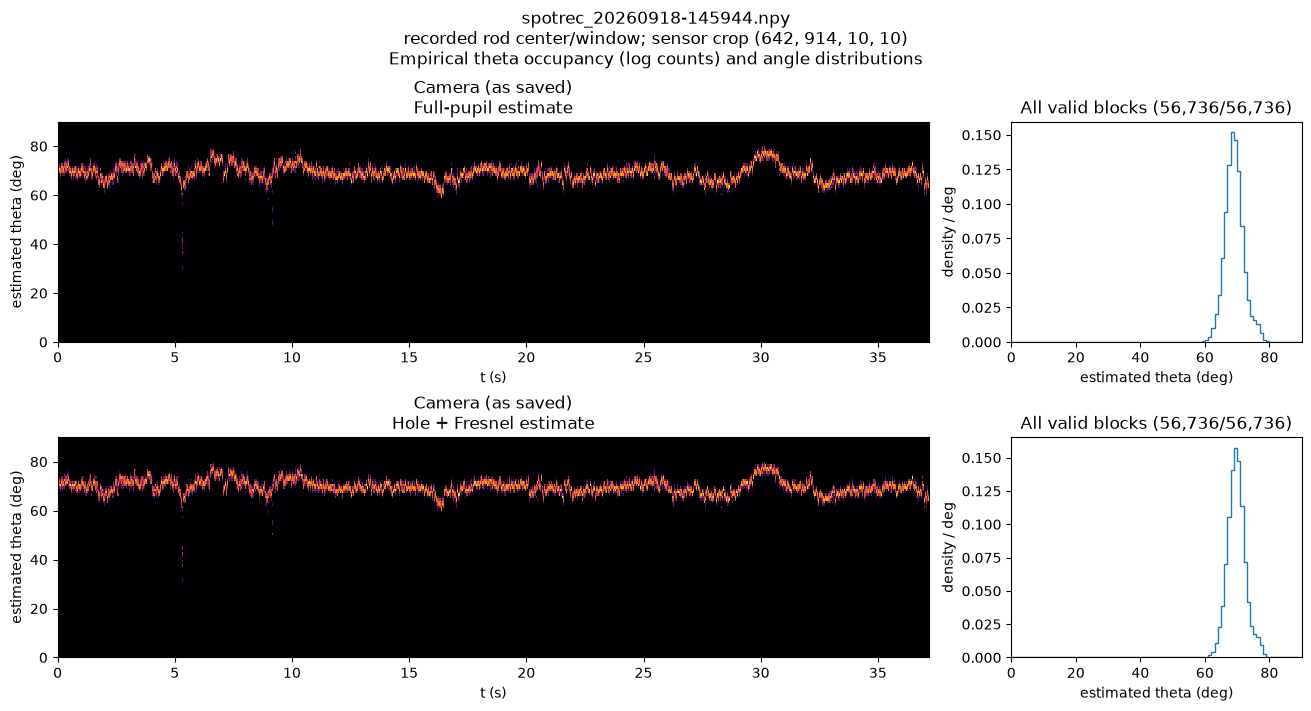

spotrec_20260918-145944.npy: 56,736 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[2/22] spotrec_20260918-151039.npy
spotrec_20260918-151039.npy: camera 1526.40264 FPS, 14,862 frames; marker removed=True; recorded rod center/window, crop=(642, 914, 10, 10); acquisition background subtraction=True.


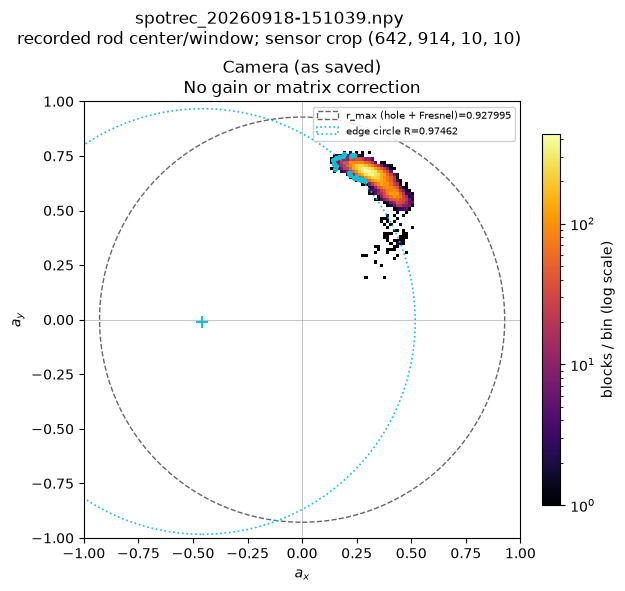

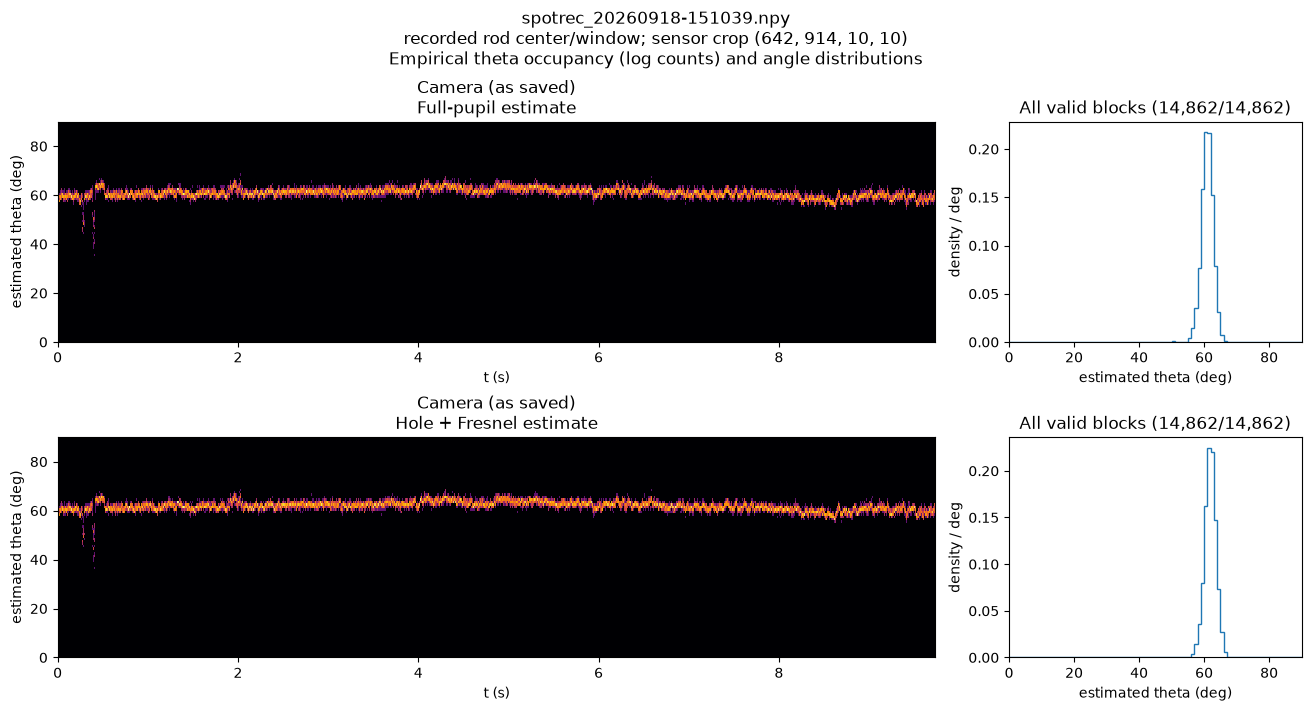

spotrec_20260918-151039.npy: 14,862 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[3/22] spotrec_20260918-151313.npy
spotrec_20260918-151313.npy: camera 1526.40264 FPS, 30,475 frames; marker removed=True; recorded rod center/window, crop=(1482, 1090, 10, 10); acquisition background subtraction=True.


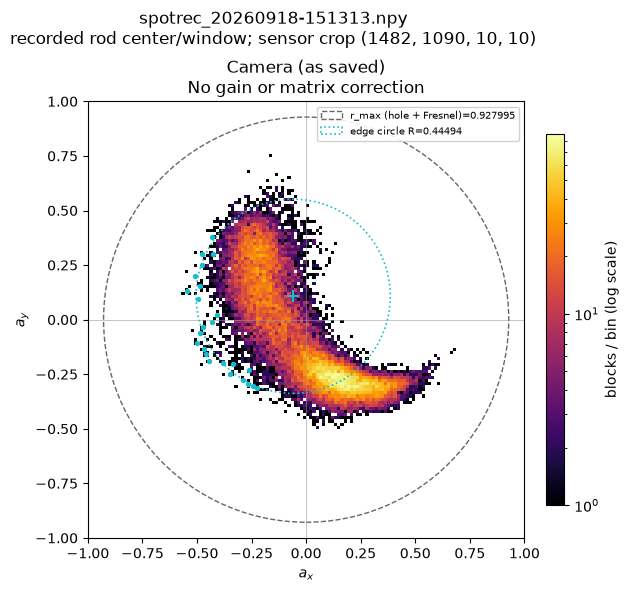

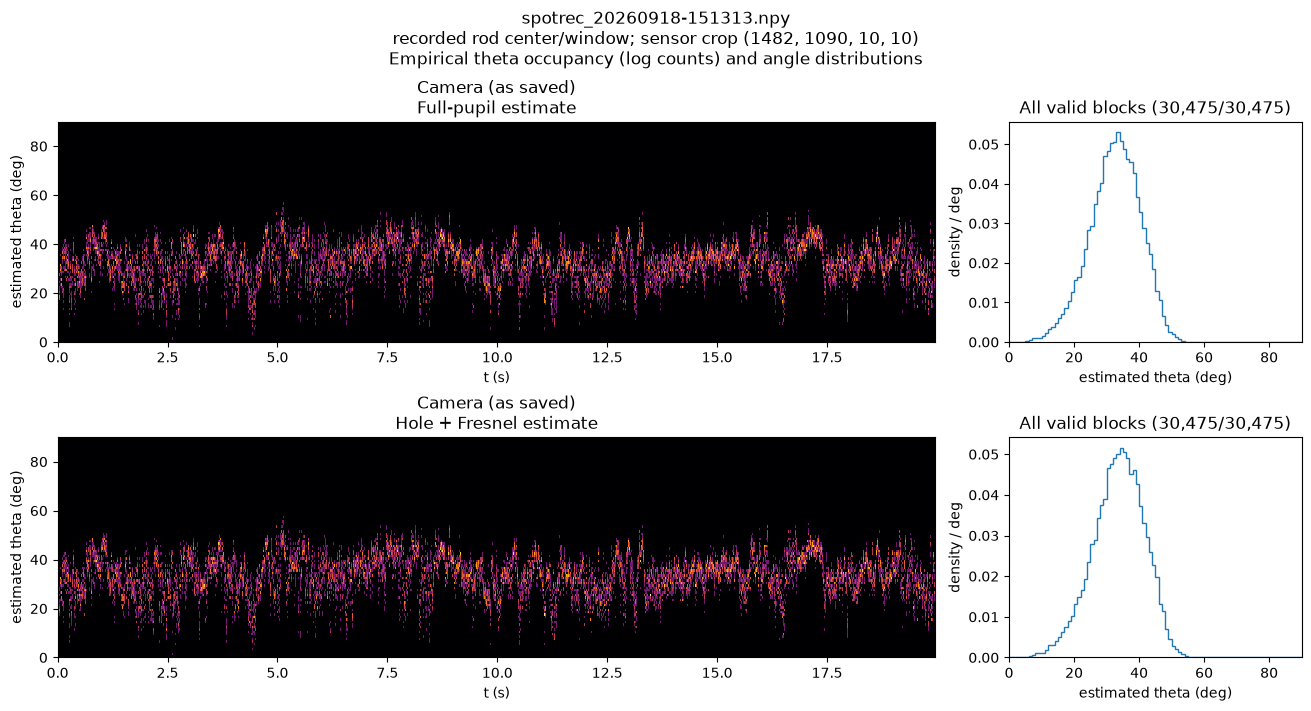

spotrec_20260918-151313.npy: 30,475 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[4/22] spotrec_20260918-151357.npy
spotrec_20260918-151357.npy: camera 1526.40264 FPS, 170,651 frames; marker removed=True; recorded rod center/window, crop=(1482, 1090, 10, 10); acquisition background subtraction=True.


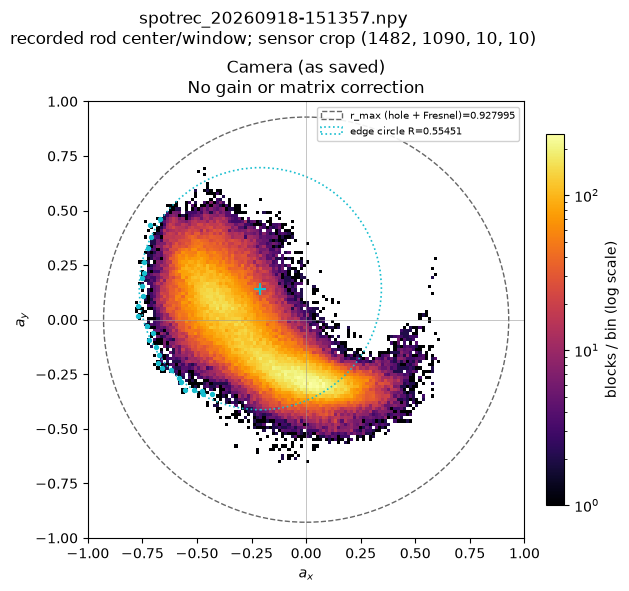

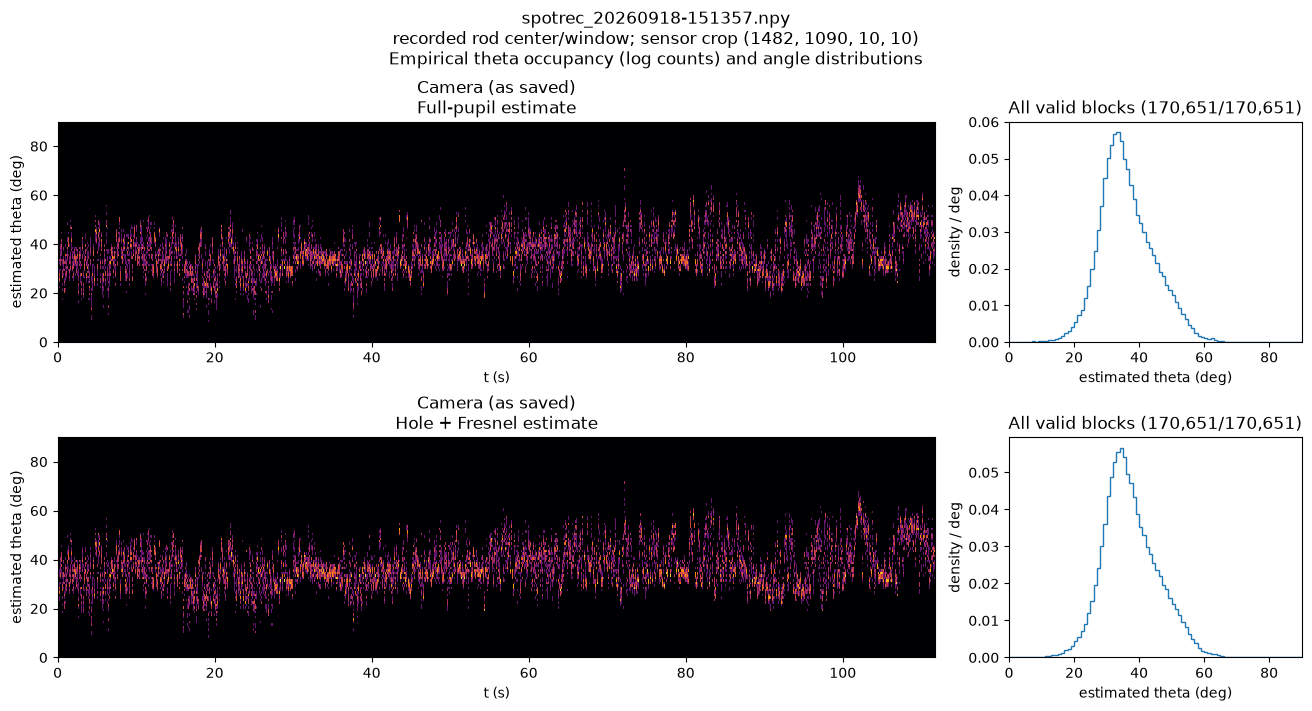

spotrec_20260918-151357.npy: 170,651 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[5/22] spotrec_20260918-151631.npy
spotrec_20260918-151631.npy: camera 1526.40264 FPS, 108,959 frames; marker removed=True; recorded rod center/window, crop=(1479, 840, 10, 10); acquisition background subtraction=True.
spotrec_20260918-151631.npy
recorded rod center/window; sensor crop (1479, 840, 10, 10): circle overlay omitted (ValueError: Circle fit is effectively unbounded relative to the observed edge span)


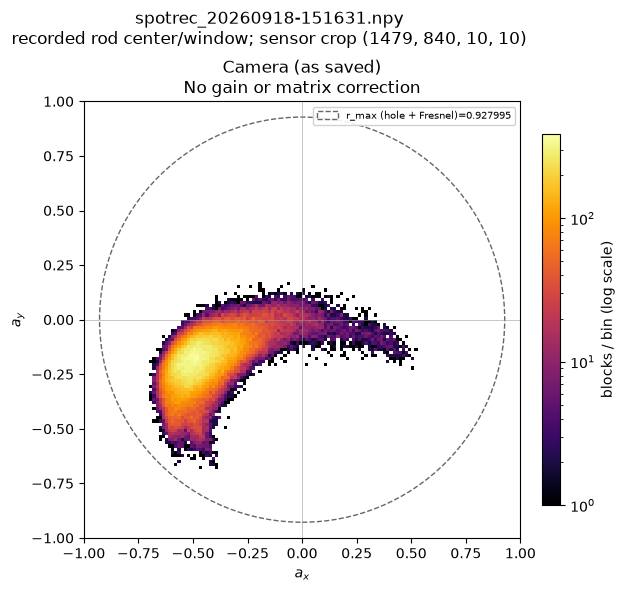

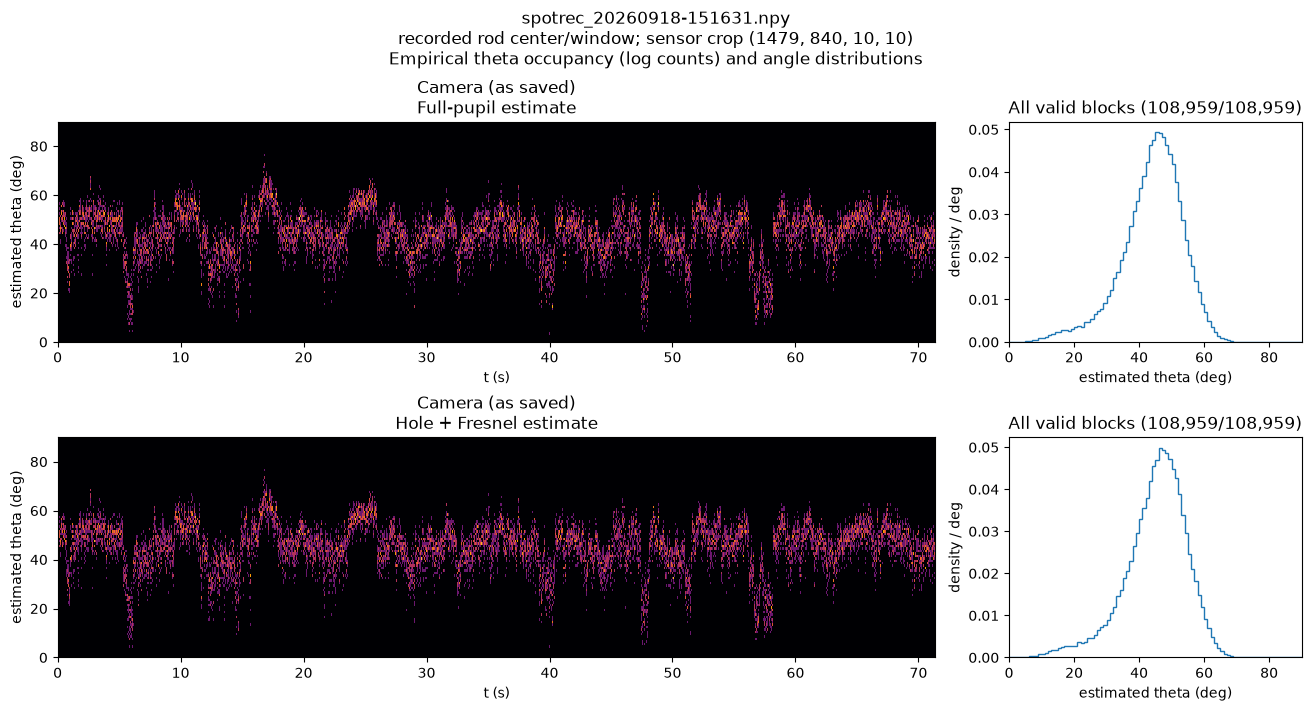

spotrec_20260918-151631.npy: 108,959 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[6/22] spotrec_20260918-151818.npy
spotrec_20260918-151818.npy: camera 1526.40264 FPS, 21,075 frames; marker removed=True; recorded rod center/window, crop=(507, 322, 10, 10); acquisition background subtraction=True.
spotrec_20260918-151818.npy
recorded rod center/window; sensor crop (507, 322, 10, 10): circle overlay omitted (ValueError: Circle fit failed: Maximum number of function evaluations has been exceeded.)


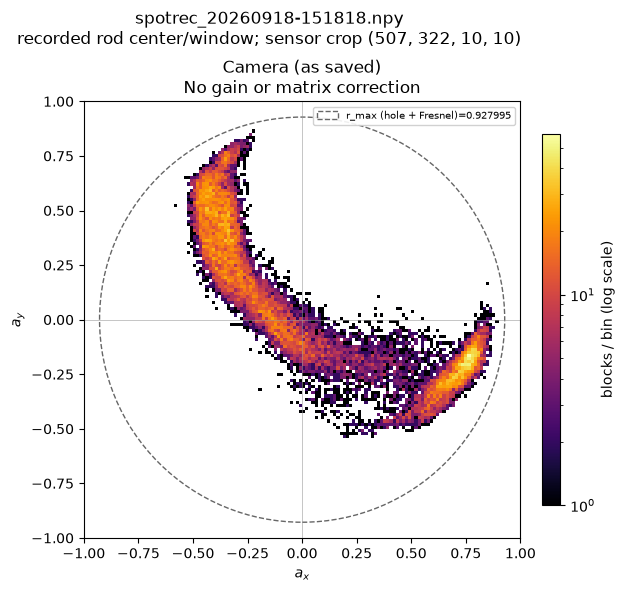

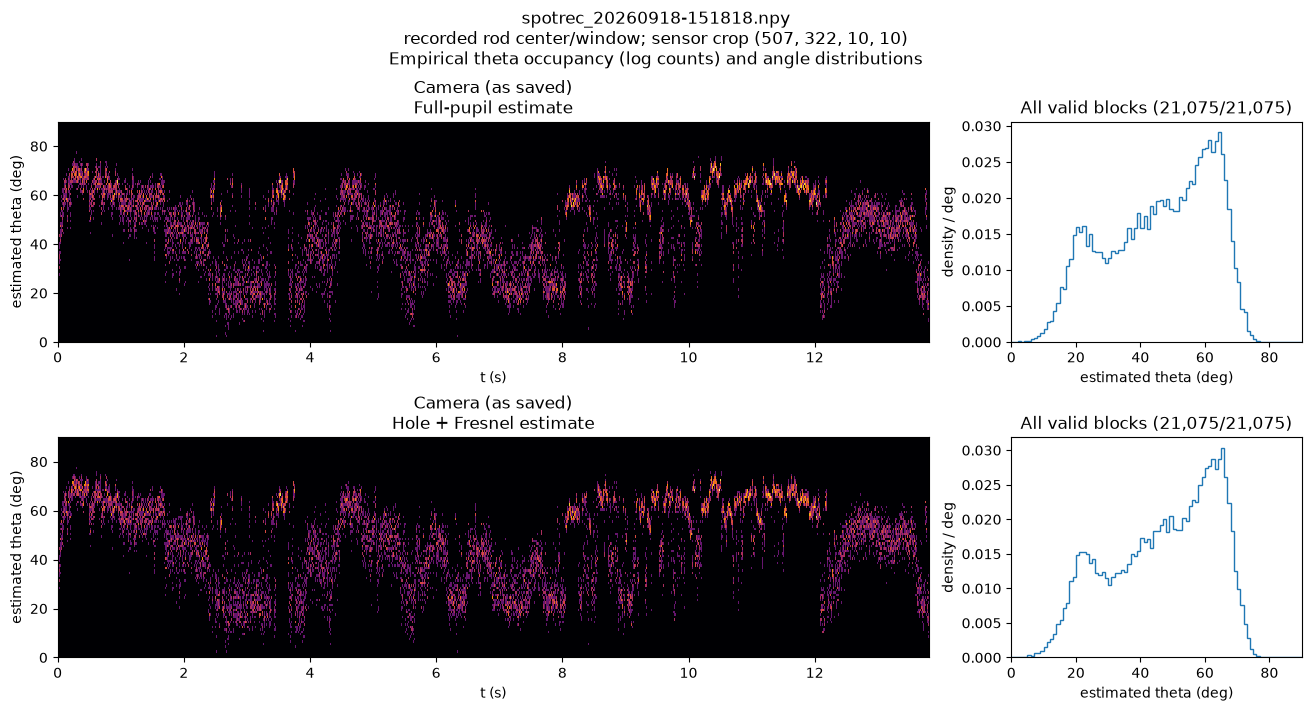

spotrec_20260918-151818.npy: 21,075 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[7/22] spotrec_20260918-151950.npy
spotrec_20260918-151950.npy: camera 1526.40264 FPS, 12,491 frames; marker removed=True; recorded rod center/window, crop=(604, 824, 10, 10); acquisition background subtraction=True.


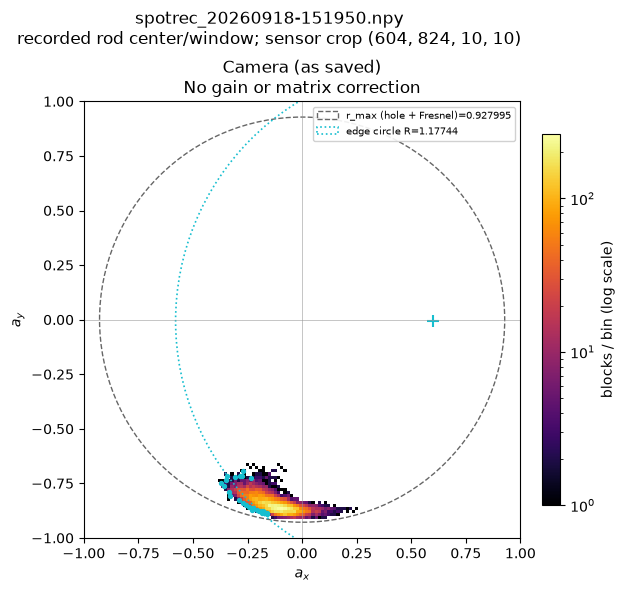

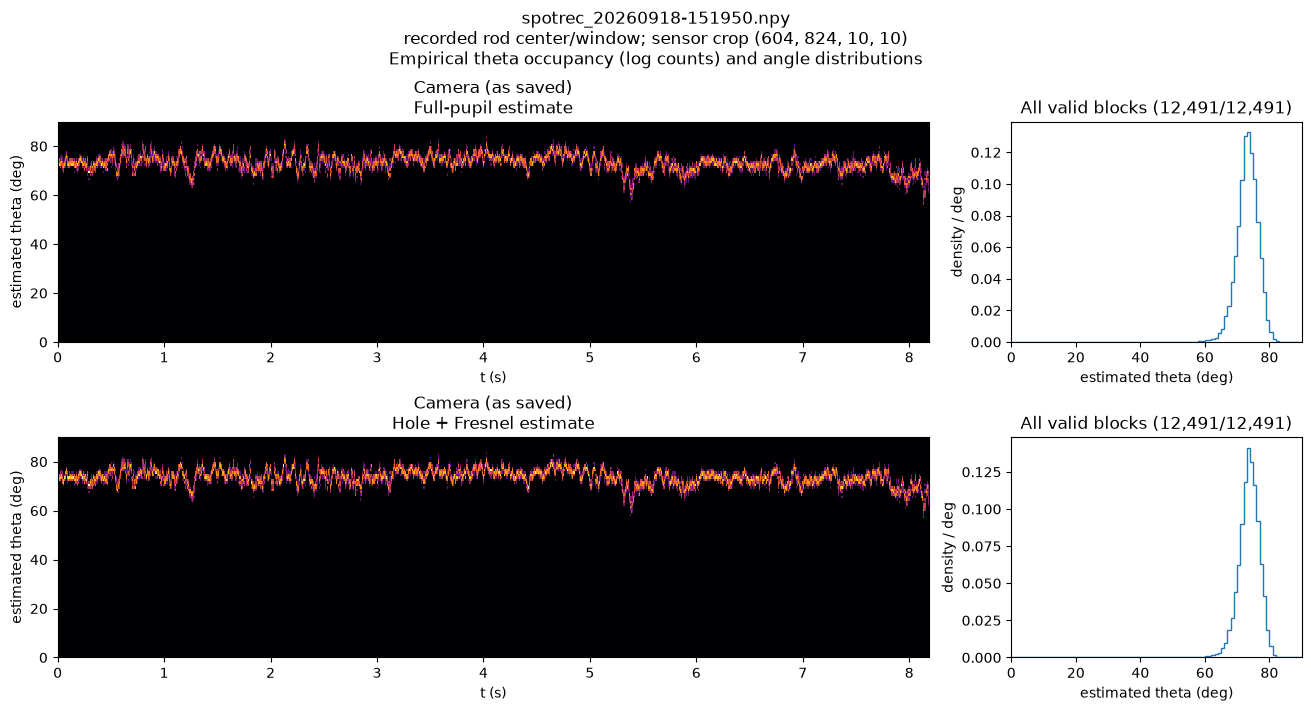

spotrec_20260918-151950.npy: 12,491 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[8/22] spotrec_20260918-152028.npy
spotrec_20260918-152028.npy: camera 1526.40264 FPS, 16,348 frames; marker removed=True; recorded rod center/window, crop=(336, 678, 10, 10); acquisition background subtraction=True.


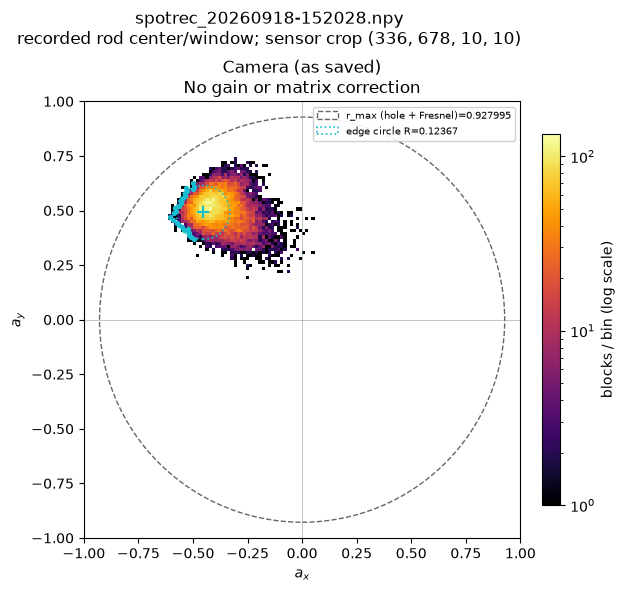

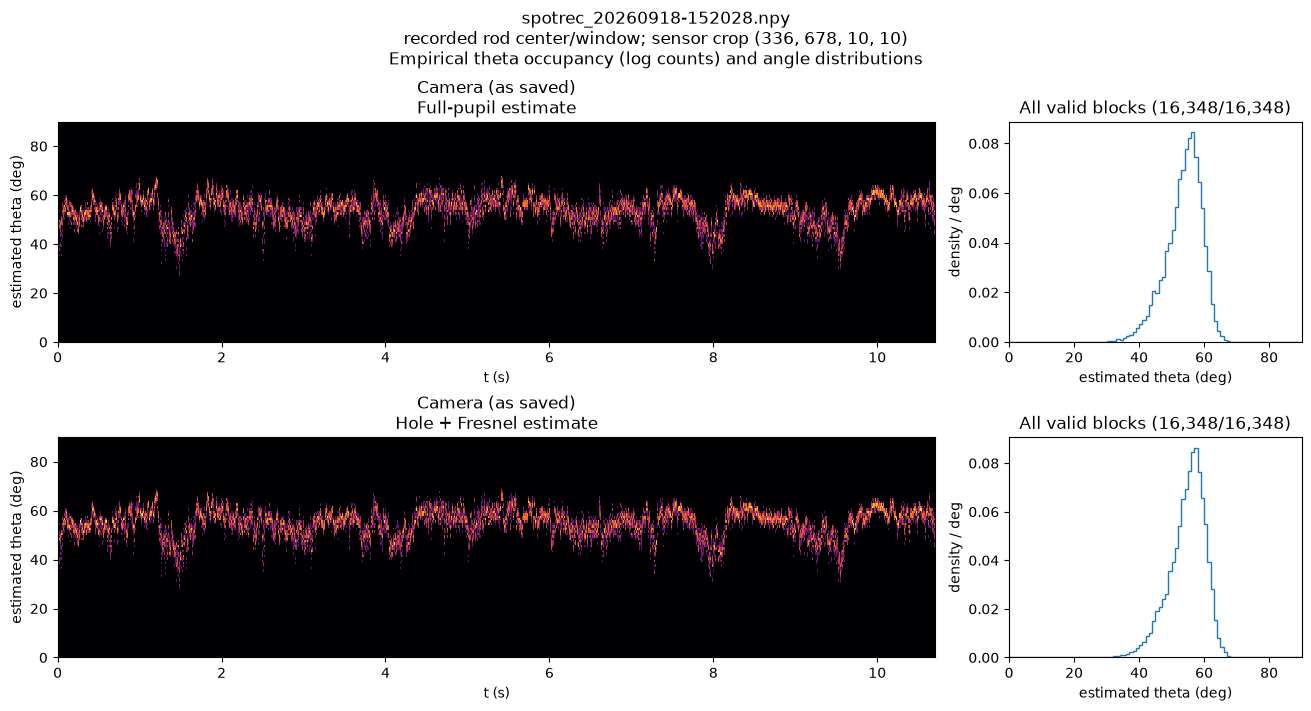

spotrec_20260918-152028.npy: 16,348 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[9/22] spotrec_20260918-152047.npy
spotrec_20260918-152047.npy: camera 1526.40264 FPS, 37,392 frames; marker removed=True; recorded rod center/window, crop=(336, 678, 10, 10); acquisition background subtraction=True.


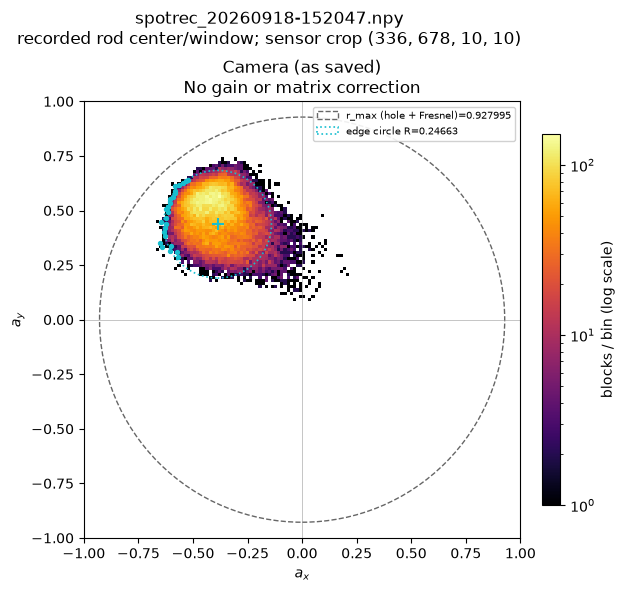

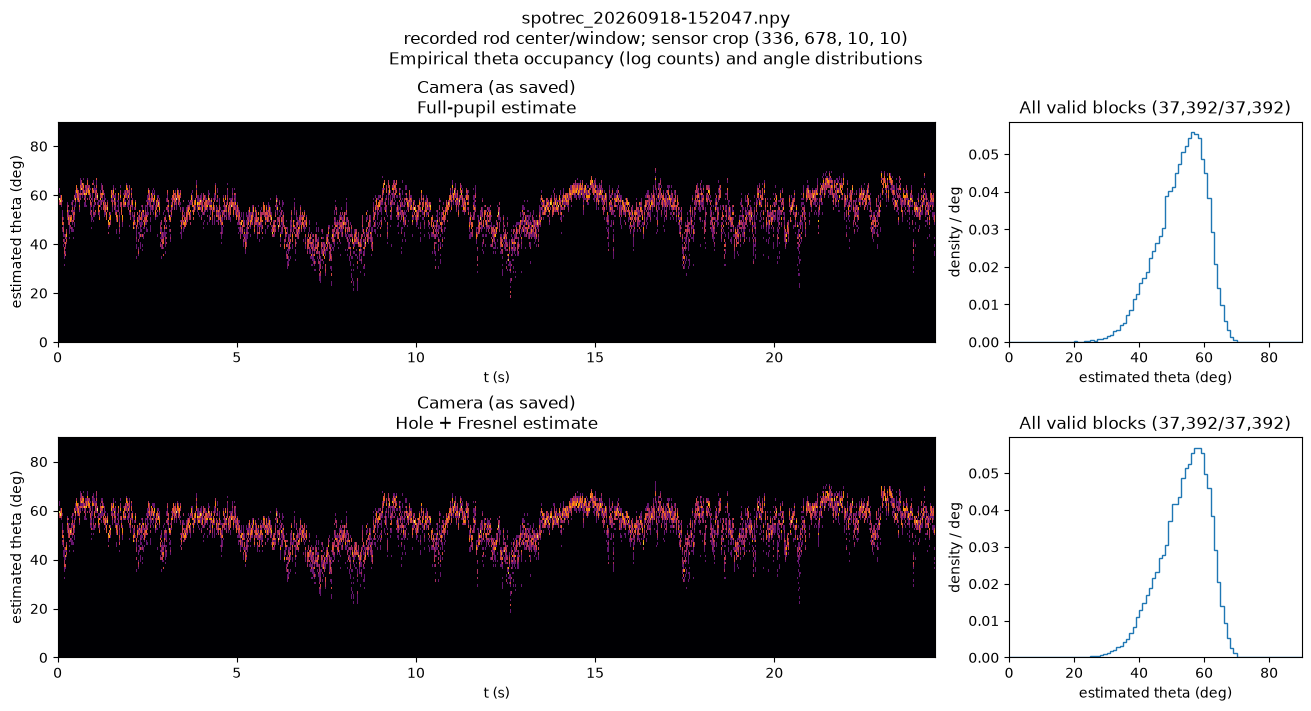

spotrec_20260918-152047.npy: 37,392 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[10/22] spotrec_20260918-152338.npy
spotrec_20260918-152338.npy: camera 1526.40264 FPS, 20,097 frames; marker removed=True; recorded rod center/window, crop=(1237, 1160, 10, 10); acquisition background subtraction=True.
spotrec_20260918-152338.npy
recorded rod center/window; sensor crop (1237, 1160, 10, 10): circle overlay omitted (ValueError: Circle fit failed: Maximum number of function evaluations has been exceeded.)


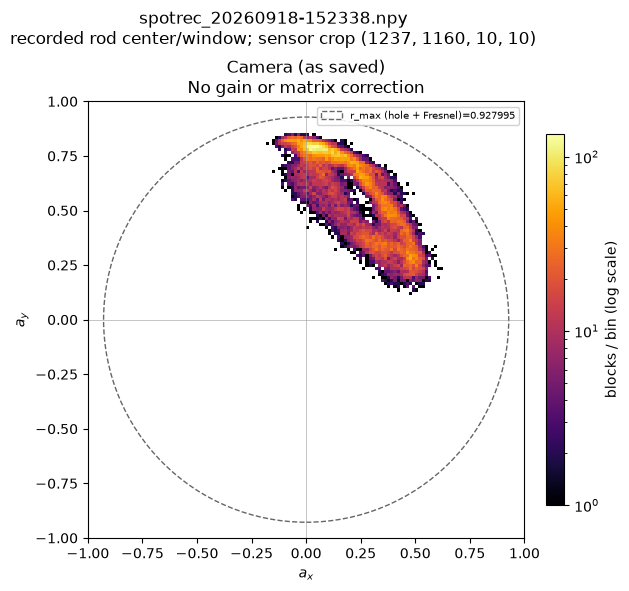

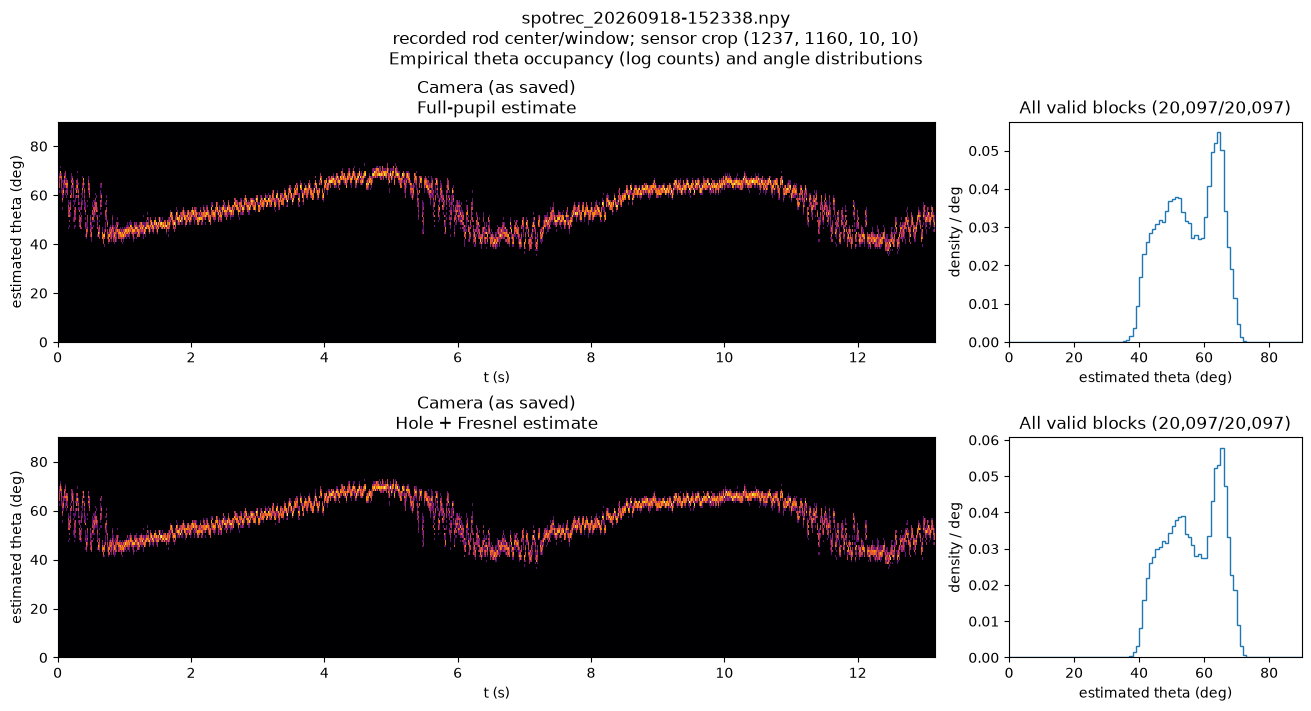

spotrec_20260918-152338.npy: 20,097 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[11/22] spotrec_20260918-152425.npy
spotrec_20260918-152425.npy: camera 1526.40264 FPS, 18,861 frames; marker removed=True; recorded rod center/window, crop=(1237, 1160, 10, 10); acquisition background subtraction=True.


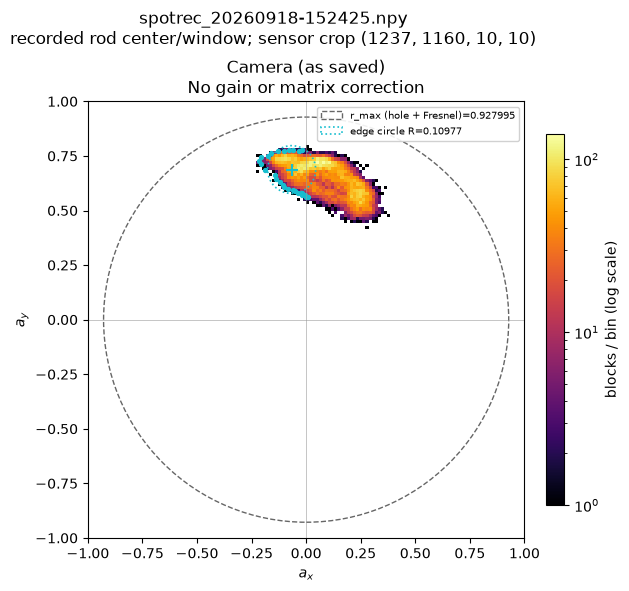

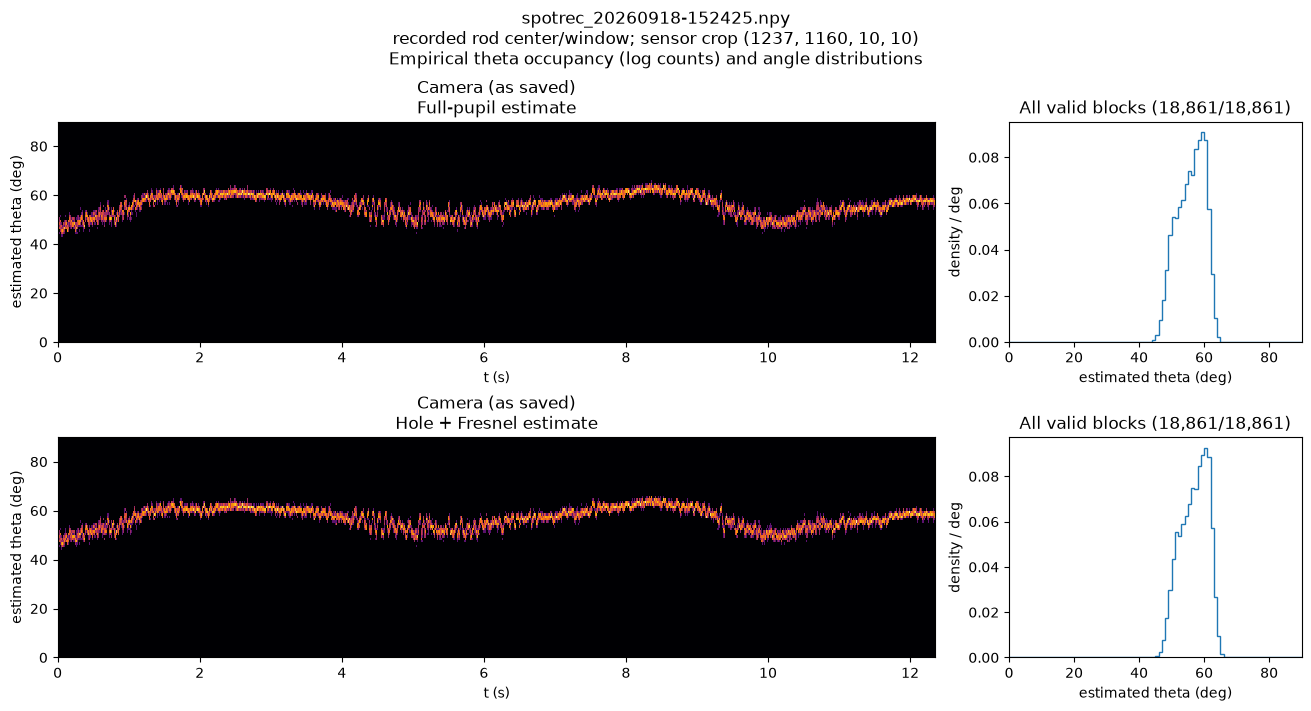

spotrec_20260918-152425.npy: 18,861 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[12/22] spotrec_20260918-152535.npy
spotrec_20260918-152535.npy: camera 1526.40264 FPS, 37,246 frames; marker removed=True; recorded rod center/window, crop=(1237, 1160, 10, 10); acquisition background subtraction=True.
spotrec_20260918-152535.npy
recorded rod center/window; sensor crop (1237, 1160, 10, 10): circle overlay omitted (ValueError: Circle fit failed: Maximum number of function evaluations has been exceeded.)


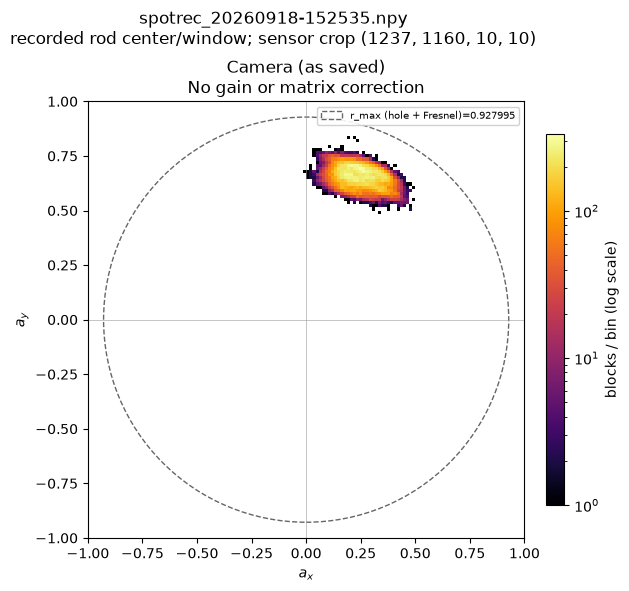

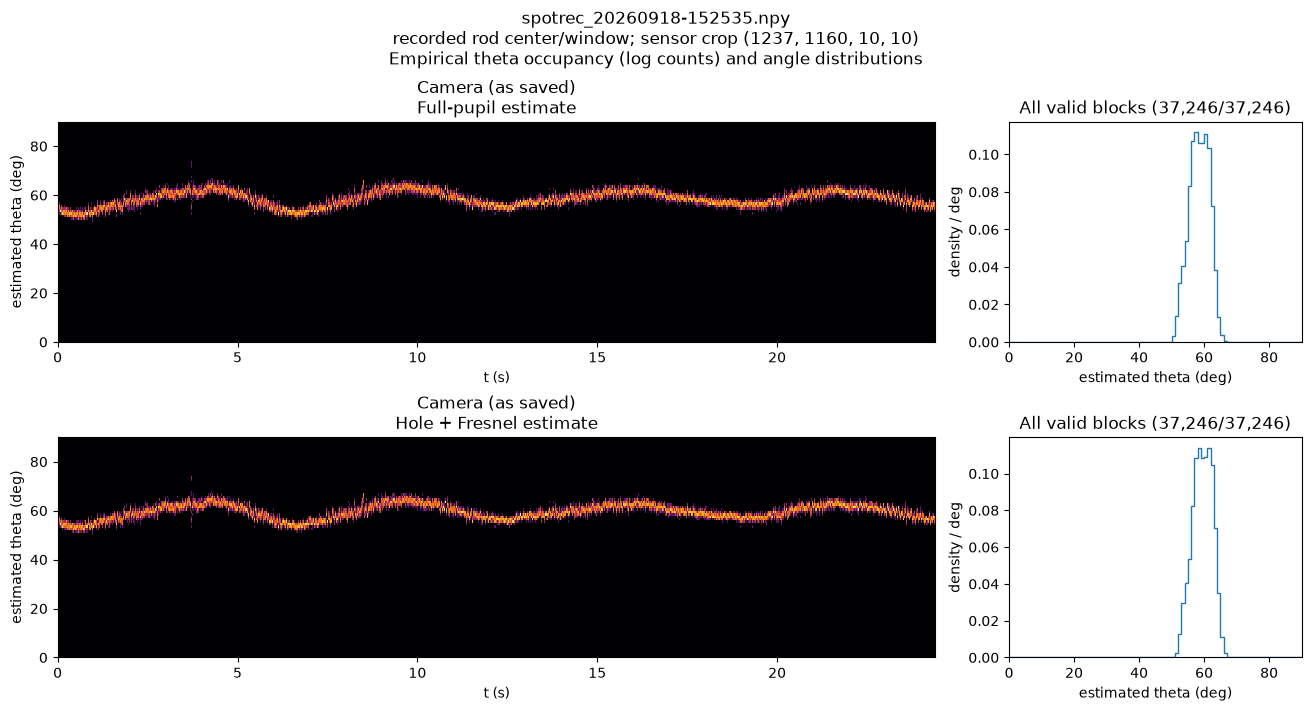

spotrec_20260918-152535.npy: 37,246 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[13/22] spotrec_20260918-152632.npy
spotrec_20260918-152632.npy: camera 1526.40264 FPS, 26,228 frames; marker removed=True; recorded rod center/window, crop=(1237, 1160, 10, 10); acquisition background subtraction=True.


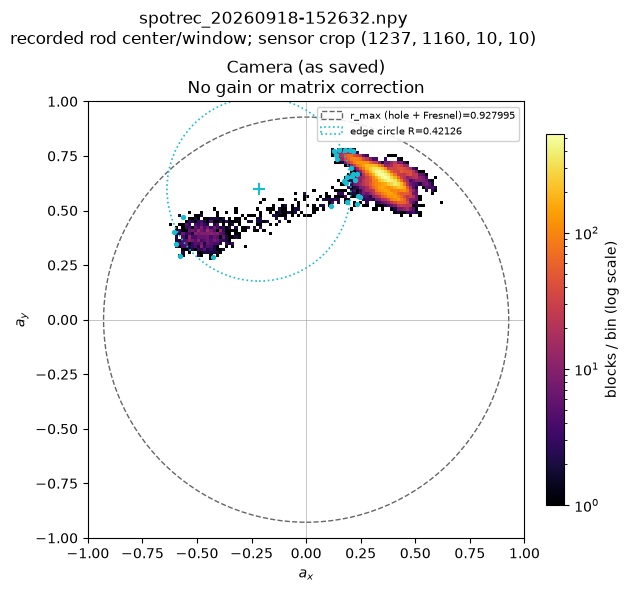

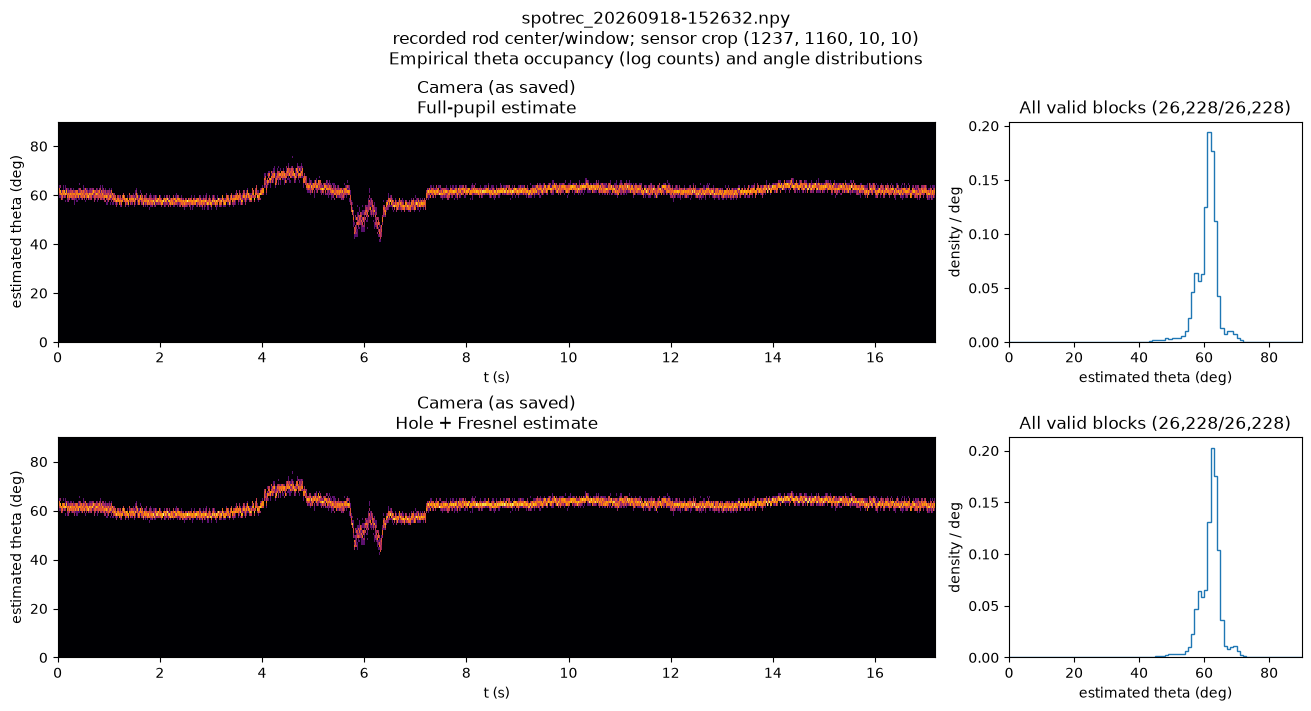

spotrec_20260918-152632.npy: 26,228 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[14/22] spotrec_20260918-152825.npy
spotrec_20260918-152825.npy: camera 1526.40264 FPS, 37,485 frames; marker removed=True; recorded rod center/window, crop=(837, 1566, 10, 10); acquisition background subtraction=True.


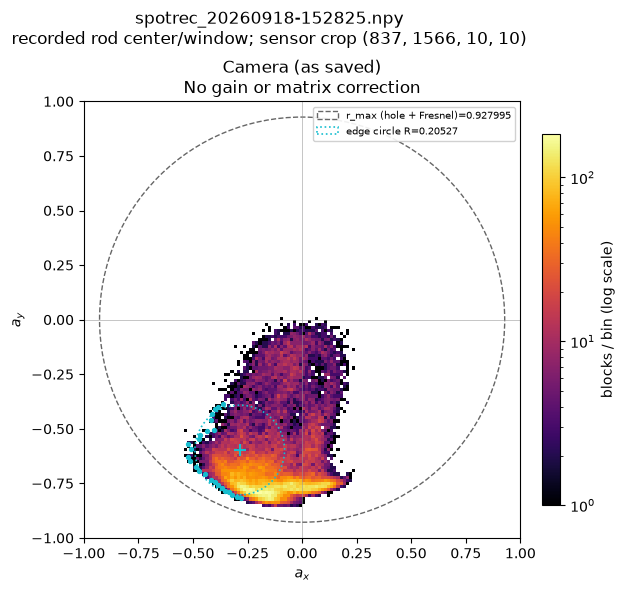

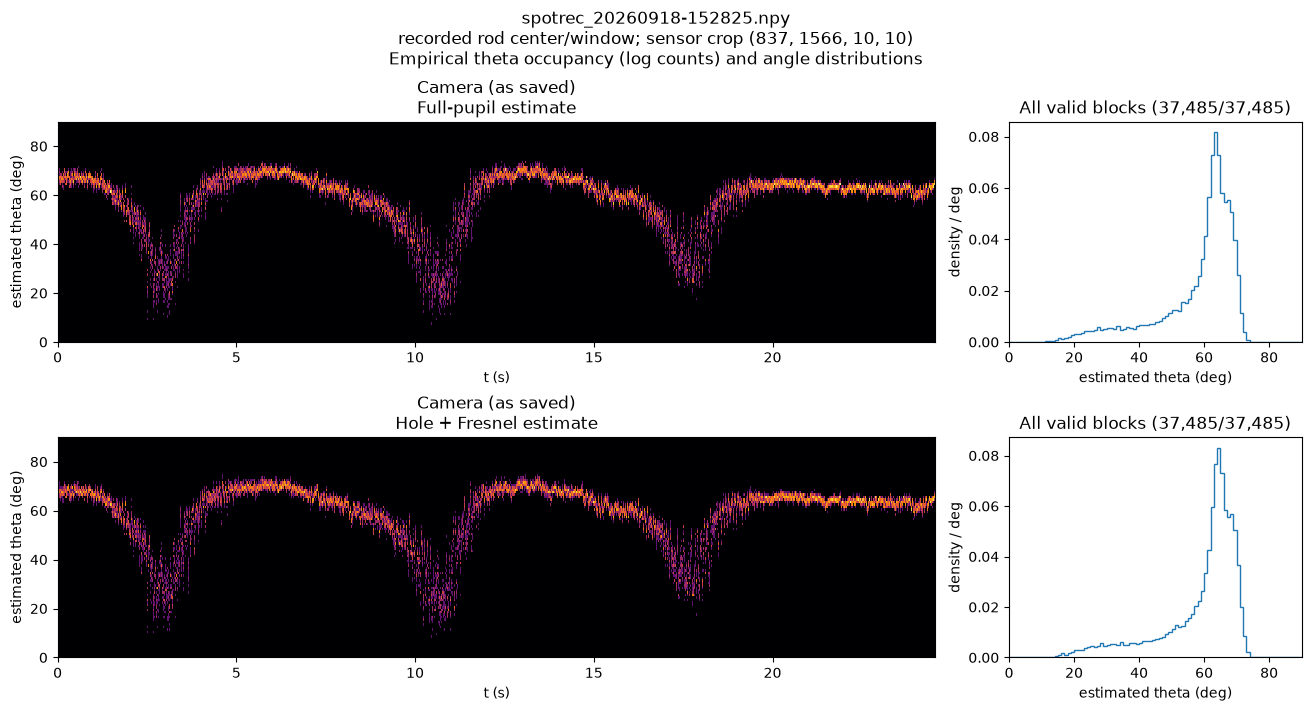

spotrec_20260918-152825.npy: 37,485 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[15/22] spotrec_20260918-152902.npy
spotrec_20260918-152902.npy: camera 1526.40264 FPS, 112,954 frames; marker removed=True; recorded rod center/window, crop=(837, 1566, 10, 10); acquisition background subtraction=True.


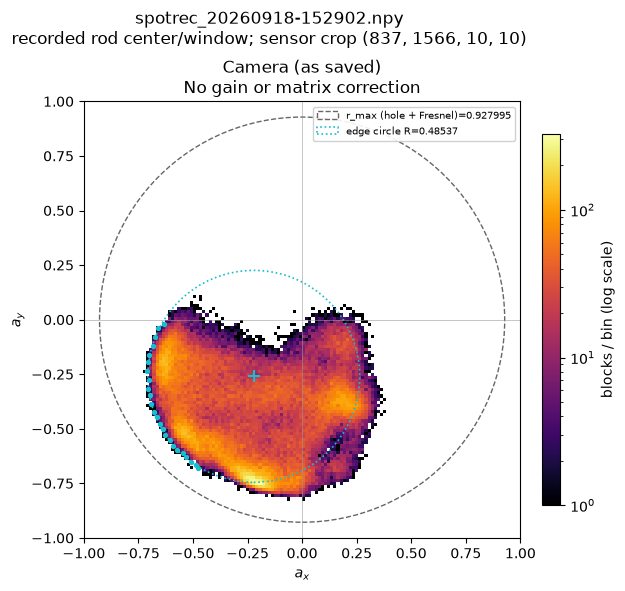

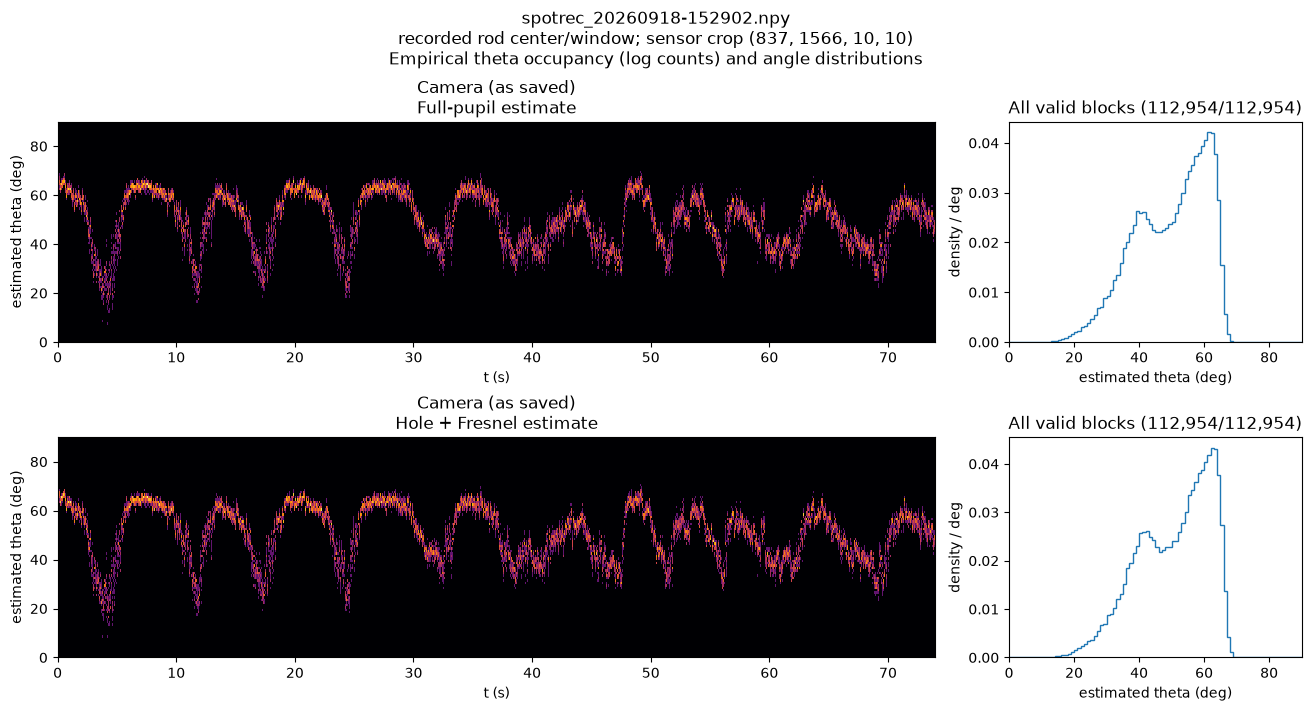

spotrec_20260918-152902.npy: 112,954 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[16/22] spotrec_20260918-154644.npy
spotrec_20260918-154644.npy: camera 1526.40264 FPS, 8,001 frames; marker removed=True; recorded rod center/window, crop=(1166, 826, 10, 10); acquisition background subtraction=True.


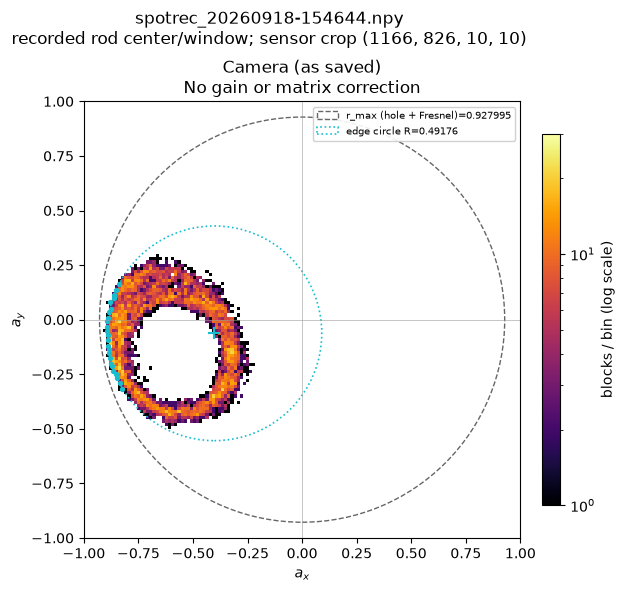

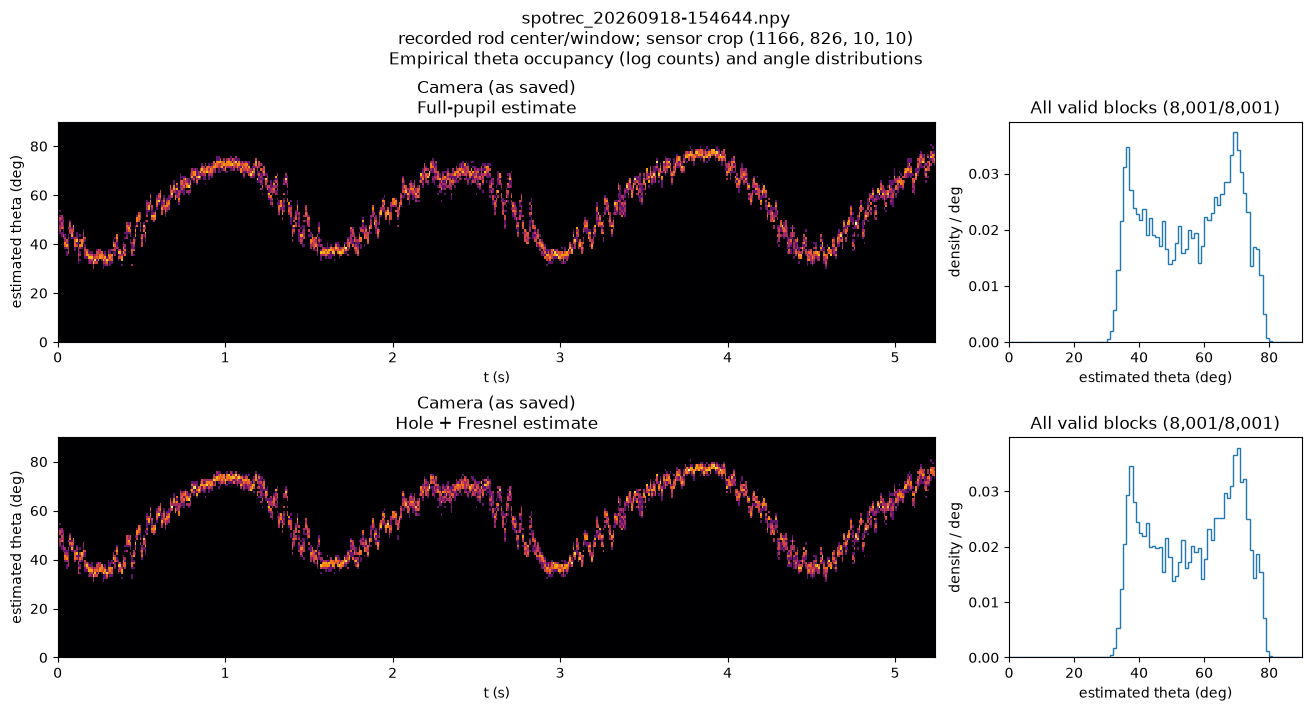

spotrec_20260918-154644.npy: 8,001 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[17/22] spotrec_20260918-154707.npy
spotrec_20260918-154707.npy: camera 1526.40264 FPS, 90,465 frames; marker removed=True; recorded rod center/window, crop=(1166, 826, 10, 10); acquisition background subtraction=True.


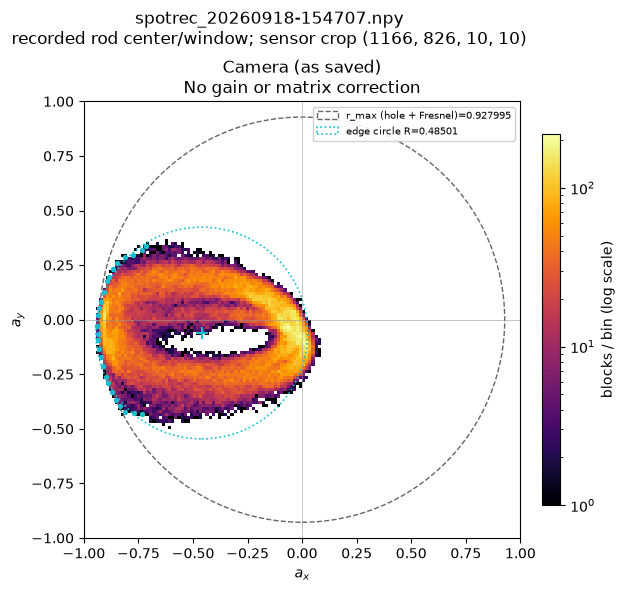

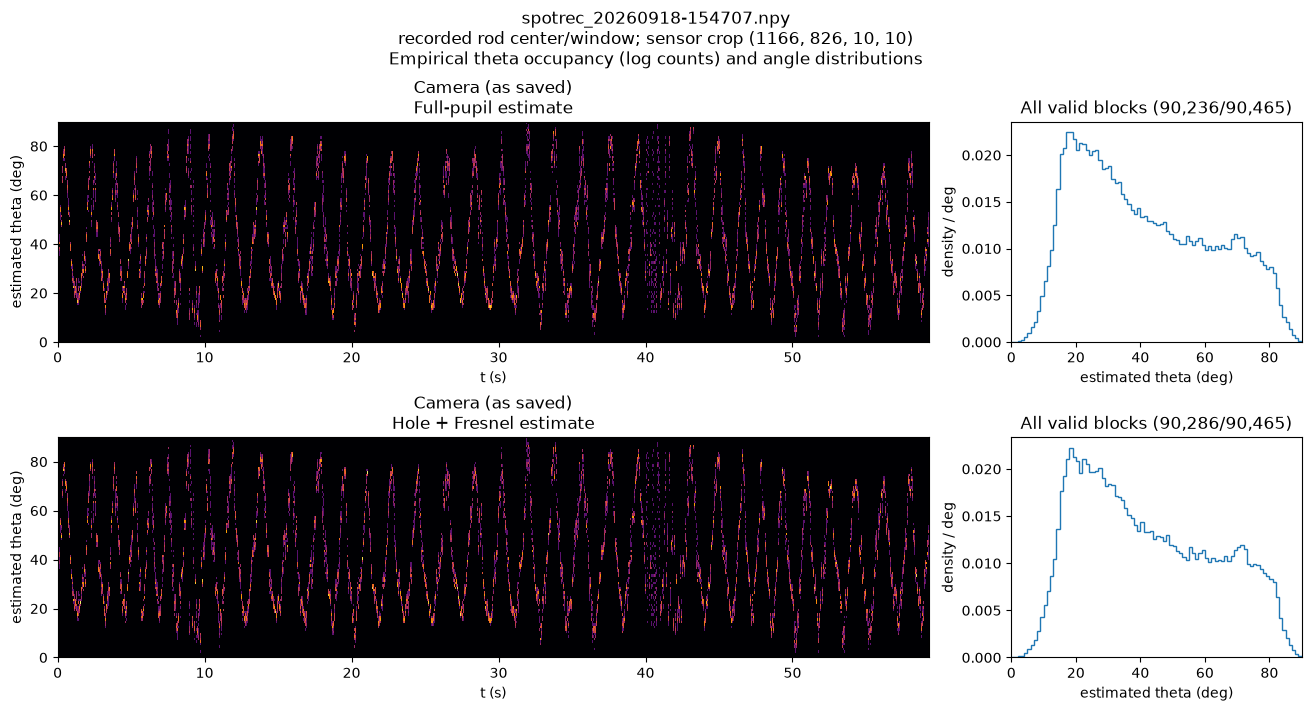

spotrec_20260918-154707.npy: 90,465 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[18/22] spotrec_20260918-154835.npy
spotrec_20260918-154835.npy: camera 1526.40264 FPS, 22,352 frames; marker removed=True; recorded rod center/window, crop=(1039, 738, 10, 10); acquisition background subtraction=True.


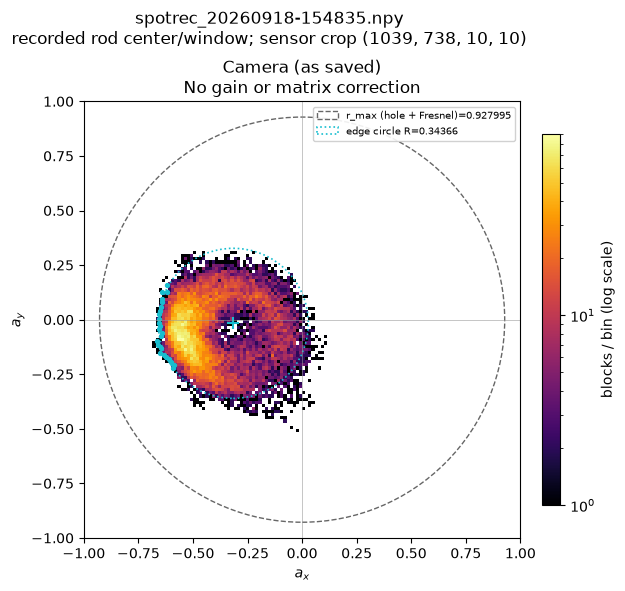

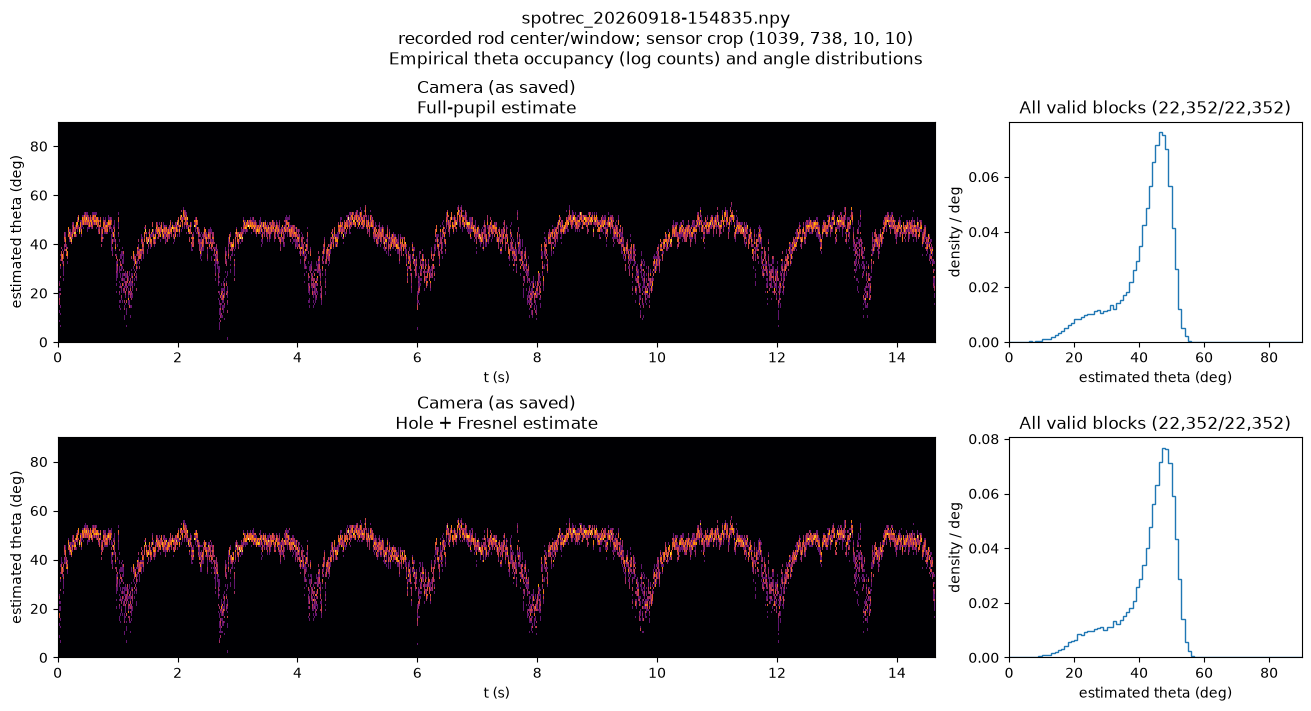

spotrec_20260918-154835.npy: 22,352 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[19/22] spotrec_20260918-155201.npy
spotrec_20260918-155201.npy: camera 1526.40264 FPS, 20,950 frames; marker removed=True; recorded rod center/window, crop=(1172, 716, 10, 10); acquisition background subtraction=True.


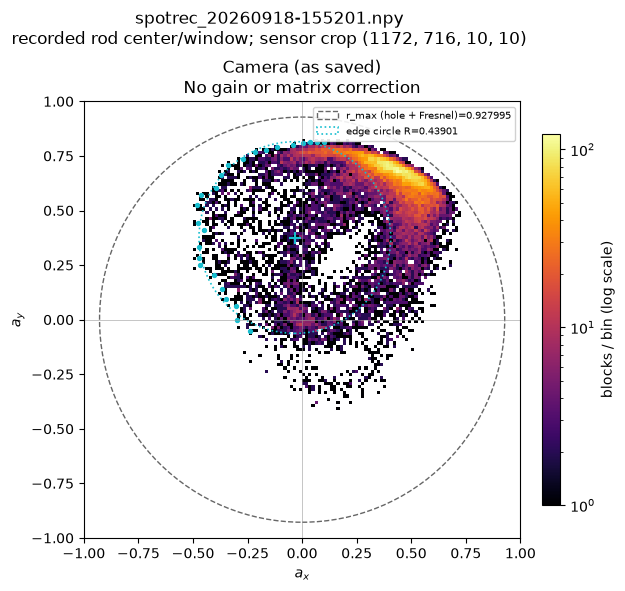

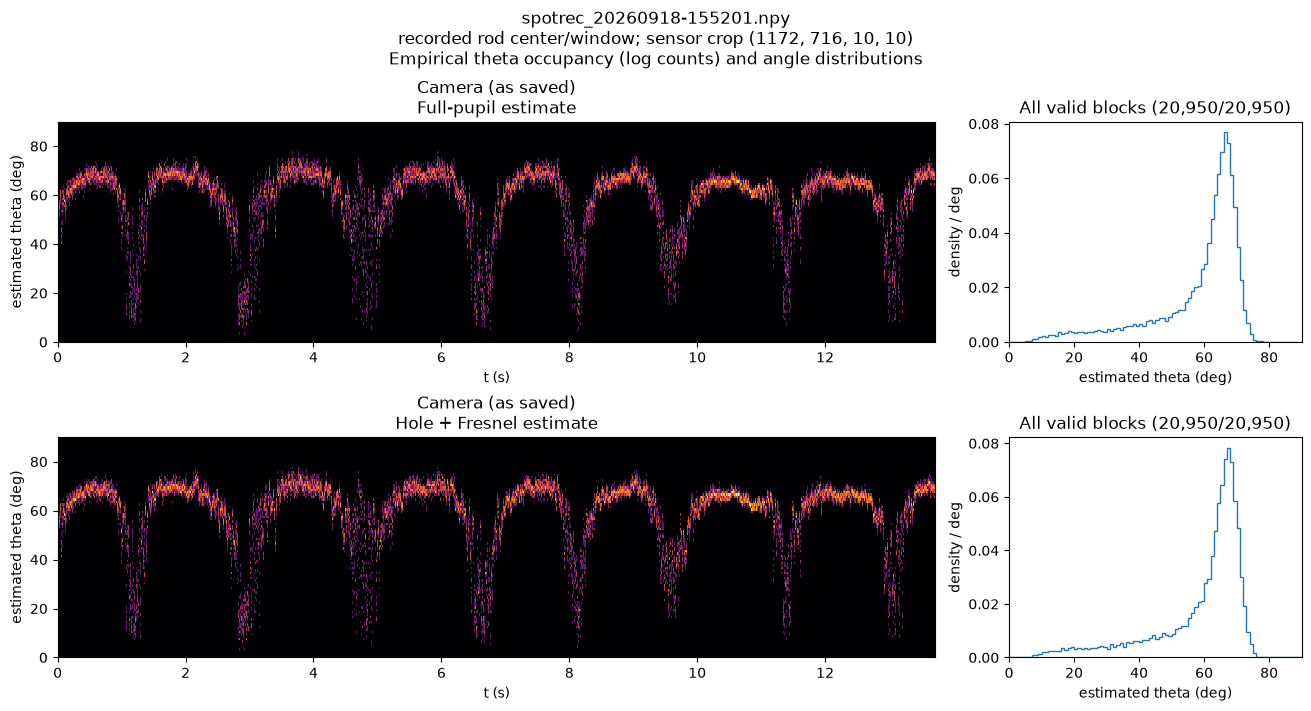

spotrec_20260918-155201.npy: 20,950 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[20/22] spotrec_20260918-155250.npy
spotrec_20260918-155250.npy: camera 1526.40264 FPS, 11,049 frames; marker removed=True; recorded rod center/window, crop=(540, 688, 10, 10); acquisition background subtraction=True.


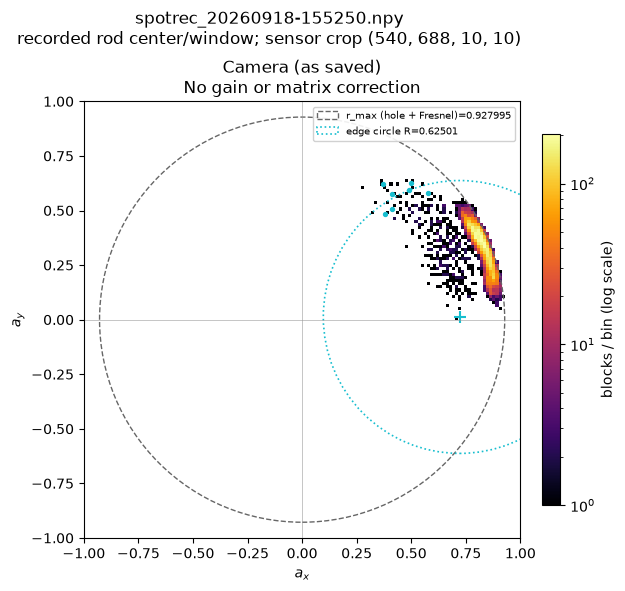

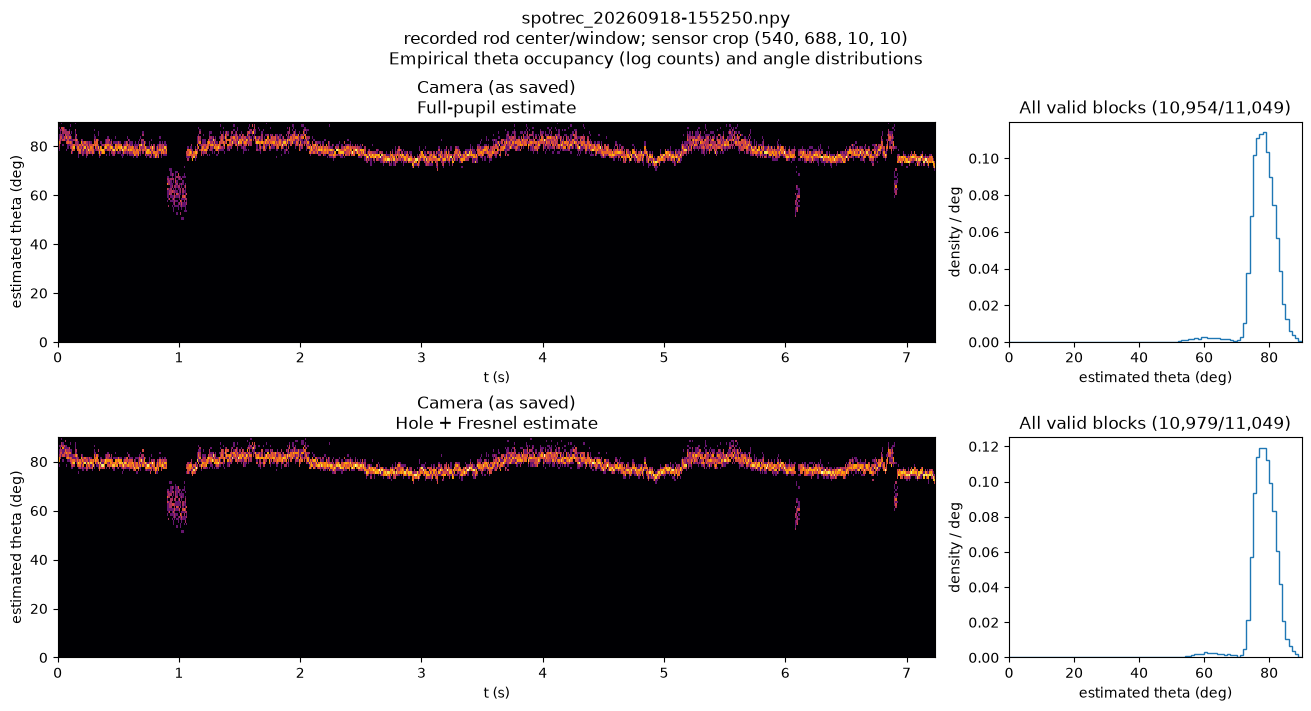

spotrec_20260918-155250.npy: 11,049 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[21/22] spotrec_20260918-155316.npy
spotrec_20260918-155316.npy: camera 1526.40264 FPS, 34,653 frames; marker removed=True; recorded rod center/window, crop=(540, 688, 10, 10); acquisition background subtraction=True.


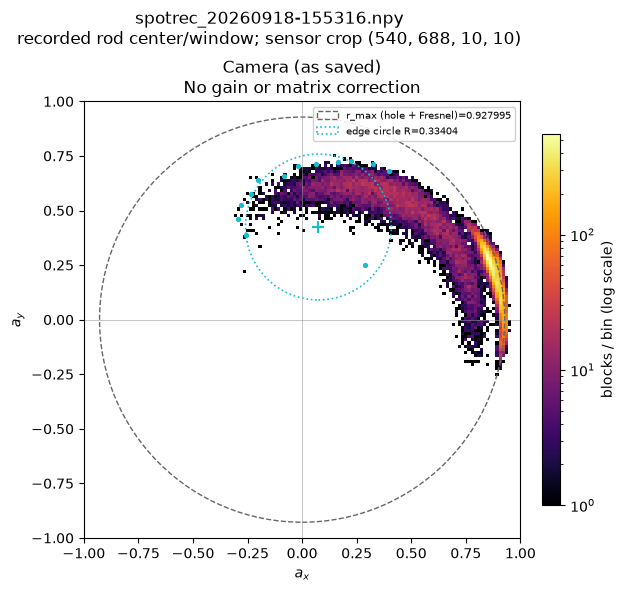

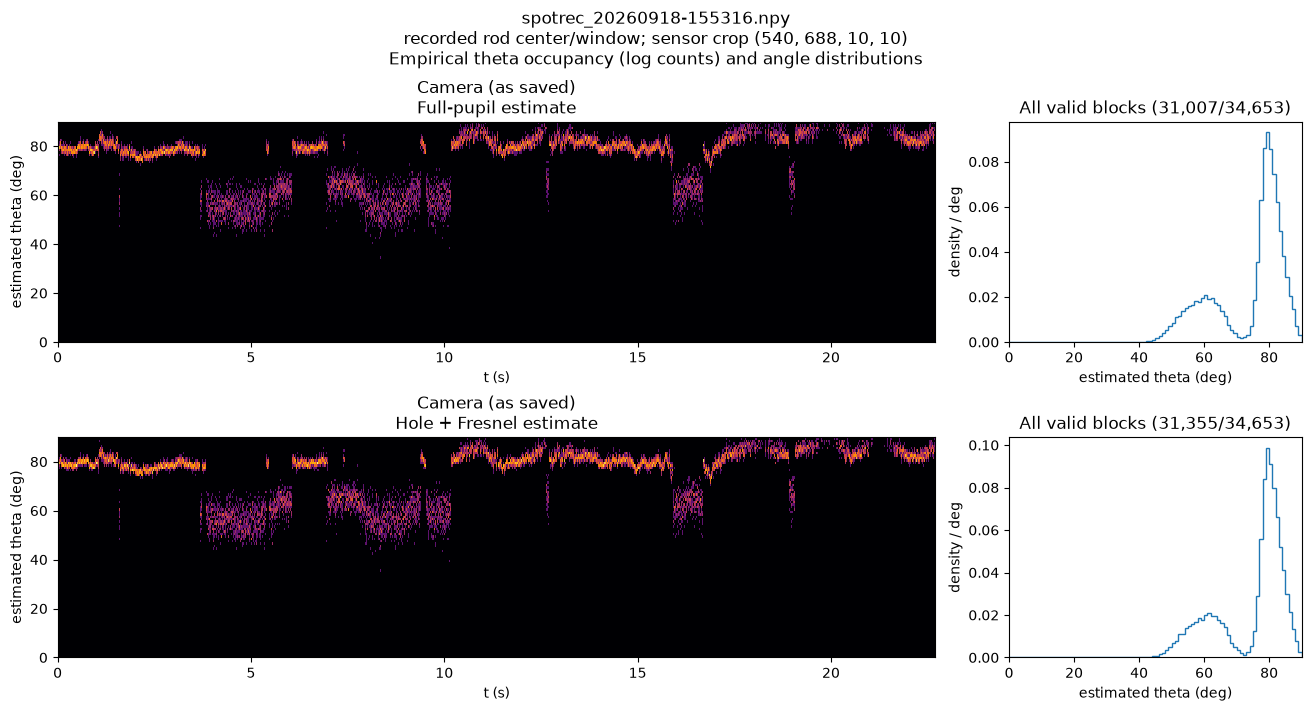

spotrec_20260918-155316.npy: 34,653 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

[22/22] spotrec_20260918-155645.npy
spotrec_20260918-155645.npy: camera 1526.40264 FPS, 29,628 frames; marker removed=True; recorded rod center/window, crop=(540, 688, 10, 10); acquisition background subtraction=True.


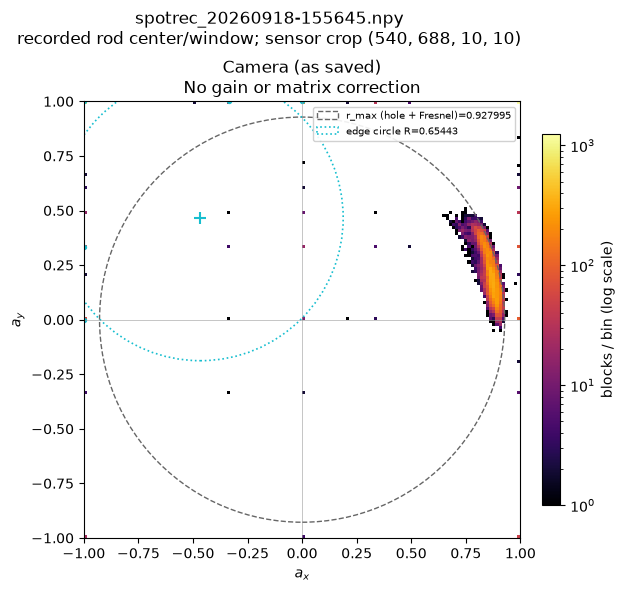

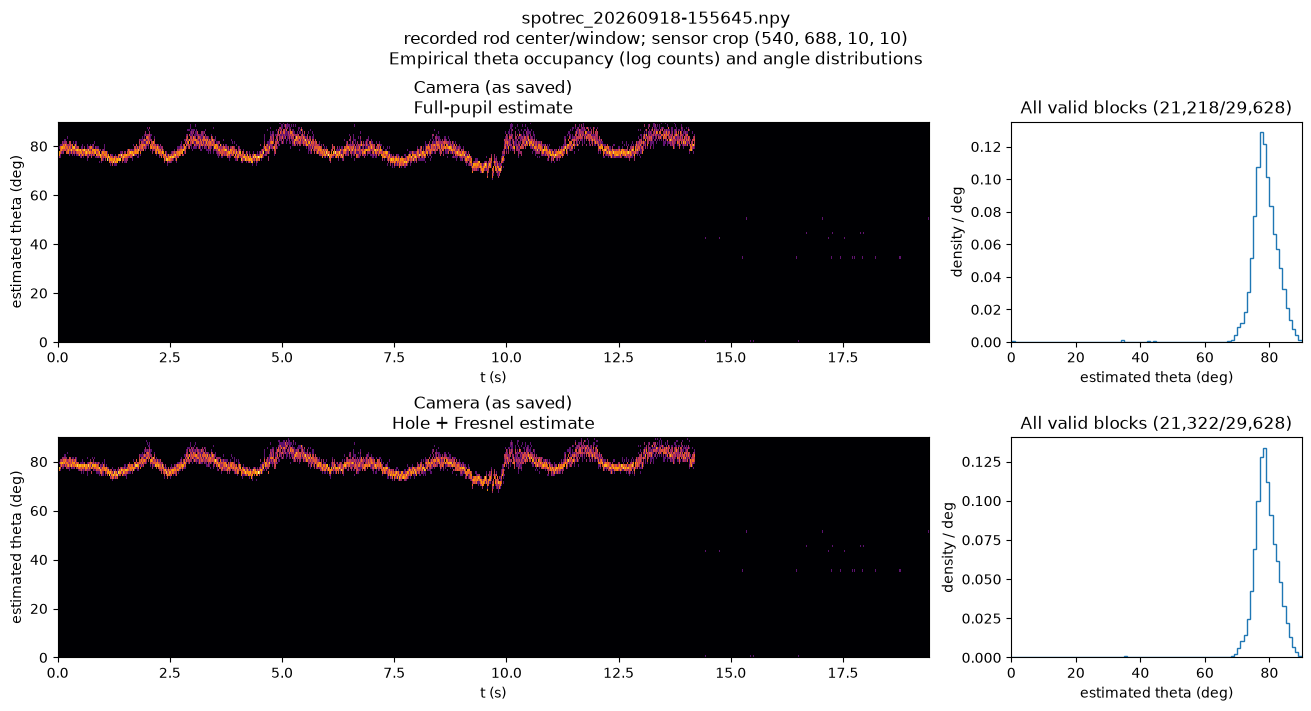

spotrec_20260918-155645.npy: 29,628 blocks at 655.135 us; 0 trailing samples omitted; no gain or matrix correction

Finished: 22 succeeded, 0 failed. Output: C:\Users\denny\workspace\anisotropy-rotation-analysis\data\remember to correct save pathing from hugh\overview_plots


In [22]:
def process_file(path, relative_path, output_dir, coefficients, show_plots=True):
    previous_figures = set(plt.get_fignums())
    try:
        camera = path.suffix.lower() == '.npy'
        camera_info = None
        if camera:
            channels, rate, camera_info = load_camera(
                path, fps_fallback=CAMERA_FPS_FALLBACK, origin_fallback=CAMERA_ORIGIN_FALLBACK_XY,
                crop_xywh=CAMERA_CROP_XYWH)
        else:
            channels, rate = load_channels(path)
        data = prepare_recording(channels, rate, BLOCK_US, coefficients, correct_apd=not camera)
        del channels
        label = relative_path.as_posix()
        plot_label = label
        if camera_info is not None:
            plot_label += f'\n{camera_info["crop_source"]}; sensor crop {camera_info["crop_xywh"]}'
            print(f'{label}: camera {rate:.9g} FPS, {camera_info["frames"]:,} frames; '
                  f'marker removed={camera_info["marker_removed"]}; {camera_info["crop_source"]}, '
                  f'crop={camera_info["crop_xywh"]}; acquisition background subtraction={camera_info["background_subtracted"]}.')
        with plt.ioff():
            figures = make_figures(data, plot_label, fit_rim=FIT_CIRCLE, theta_time_bin_s=THETA_TIME_BIN_S)
            destination = output_dir / relative_path.parent
            destination.mkdir(parents=True, exist_ok=True)
            outputs = []
            output_stem = relative_path.name if camera else relative_path.stem
            for name, figure in zip(('anisotropy', 'theta'), figures):
                output_path = destination / f'{output_stem}_{name}.png'
                figure.savefig(output_path, dpi=150, bbox_inches='tight')
                outputs.append(str(output_path))
                if show_plots:
                    display(figure)
        correction_text = ('no gain or matrix correction' if camera else
                           f'gains [0,90,45,135]={np.round(data["gains"], 6)}')
        print(f'{label}: {len(data["times"]):,} blocks at {data["block_us"]:g} us; '
              f'{data["trailing_samples"]} trailing samples omitted; {correction_text}')
        return dict(file=label, status='ok', outputs=outputs, source=data['source'], camera=camera_info)
    finally:
        for figure_number in set(plt.get_fignums()) - previous_figures:
            plt.close(figure_number)

def scan_folder(data_dir, output_dir, *, recursive=True, show_plots=True):
    data_dir = Path(data_dir).expanduser().resolve()
    output_dir = Path(output_dir).expanduser().resolve()
    if not data_dir.is_dir():
        raise FileNotFoundError(f'Data folder does not exist: {data_dir}')
    if not np.all(np.isfinite([BLOCK_US, THETA_TIME_BIN_S])) or min(BLOCK_US, THETA_TIME_BIN_S) <= 0:
        raise ValueError('BLOCK_US and THETA_TIME_BIN_S must be positive and finite')
    coefficients = {'full': full_pupil_coefficients(NA, N_WATER),
                    'fresnel': fresnel_coefficients(NA, N_WATER, N_OIL, NA_IN)}
    candidates = data_dir.rglob('*') if recursive else data_dir.iterdir()
    paths = sorted((path for path in candidates if path.is_file() and path.suffix.lower() in ('.tdms', '.npy')
                    and not path.name.lower().startswith('spotrec_preview_')),
                   key=lambda path: path.relative_to(data_dir).as_posix().lower())
    print(f'Found {len(paths)} recordings ({sum(path.suffix.lower() == ".tdms" for path in paths)} TDMS, '
          f'{sum(path.suffix.lower() == ".npy" for path in paths)} camera NPY) in {data_dir}')
    results = []
    for file_number, path in enumerate(paths, 1):
        relative_path = path.relative_to(data_dir)
        print(f'\n[{file_number}/{len(paths)}] {relative_path.as_posix()}')
        try:
            results.append(process_file(path, relative_path, output_dir, coefficients, show_plots))
        except Exception as error:
            message = f'{type(error).__name__}: {error}'
            print(f'SKIPPED {relative_path.as_posix()}: {message}')
            results.append(dict(file=relative_path.as_posix(), status='error', error=message))
    successful = sum(result['status'] == 'ok' for result in results)
    print(f'\nFinished: {successful} succeeded, {len(results) - successful} failed. Output: {output_dir}')
    return results

SCAN_RESULTS = scan_folder(DATA_DIR, OUTPUT_DIR, recursive=RECURSIVE, show_plots=SHOW_PLOTS)